## XGBoost NHANES Diet — COALA Visualization
Counterfactuals for diabetes (HbA1c ≥ 6.5%) prediction on NHANES 2017-2018.
Mutable features: dietary intake (24-hour recall). Constraints: demographics + clinical baseline.

In [2]:
import sys
sys.path.append('~/COALA/MAP-CF/')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, os
import importlib
import cf_search.visualize
importlib.reload(cf_search.visualize)

from cf_search.visualize import (
    extract_cell_data,
    plot_counterfactuals,
    plot_cf_eta2_bar_cell,
    plot_cf_meanvalue_heatmap_cell,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_cf_eta2_bar_constraints_cell,
    plot_cellwise_grid,
    plot_by_cluster,
    tree_constraints_to_cluster_kmeans,
    get_similarity,
    report_eta2,
)
import networkx as nx

### Load data

In [3]:
output_dir        = 'public_datasets/xgb_nhanes_output'
feature_json_path = 'public_datasets/feature_categories_multi_nhanes.json'

archive_path = f'{output_dir}/counterfactuals_multi.pkl'

with open(archive_path, 'rb') as f:
    archive_data = pickle.load(f)

with open(feature_json_path, 'r') as f:
    feature_categories = json.load(f)

category_labels = list(feature_categories.keys())
num_categories = len(category_labels)

cell_feature_sets = {
    (i, j): feature_categories[category_labels[i]] + (
        feature_categories[category_labels[j]] if i != j else []
    )
    for i in range(num_categories)
    for j in range(num_categories)
}

ref_df = pd.read_csv(os.path.expanduser('~/COALA/MAP-CF/real/X_train_xgb_nhanes_diet.csv'))
color_feature = 'Waist circumference (cm)'
max_k = 3
force_k = None  # set to None to use silhouette-based selection
cluster_method = 'kmeans'
reducer = None

print(f'Loaded {len(archive_data)} individuals, {num_categories} categories')
print('Cell (0,0) sample:', extract_cell_data(archive_data, (0, 0)).columns.tolist())
#rename 2nd column in archive data to Sex (male)
for key in archive_data:
    archive_data[key].rename(columns={archive_data[key].columns[1]: 'Sex (male)'}, inplace=True)    

Loaded 200 individuals, 2 categories
Cell (0,0) sample: ['Age (years)', 'Sex (male)', 'Poverty-income ratio', 'Waist circumference (cm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 'Total cholesterol (mg/dL)', 'Smoked ≥100 cigarettes', 'Energy (kcal)', 'Carbohydrates (g)', 'Total sugars (g)', 'Total fat (g)', 'Saturated fat (g)', 'Protein (g)', 'Dietary fiber (g)', 'Sodium (mg)', 'fitness', 'cell', 'individual_id']


In [68]:
ref_df.head()

,Age (years),Sex (male),Poverty-income ratio,Waist circumference (cm),BMI,Systolic BP (mmHg),Diastolic BP (mmHg),Total cholesterol (mg/dL),Smoked ≥100 cigarettes,Energy (kcal),Carbohydrates (g),Total sugars (g),Total fat (g),Saturated fat (g),Protein (g),Dietary fiber (g),Sodium (mg)
0,22.0,0.0,2.01,110.4,32.8,108.0,64.0,111.0,1.0,1172.0,155.82,88.21,41.74,15.615,45.71,8.1,2220.0
1,63.0,1.0,2.16,103.5,33.8,128.0,86.0,190.0,1.0,1896.0,264.75,115.74,67.42,29.097,68.50,17.1,2667.0
2,79.0,0.0,1.17,83.2,22.1,166.0,62.0,226.0,0.0,1495.0,208.84,92.96,56.89,24.911,49.46,22.2,2744.0
3,63.0,1.0,2.14,119.1,33.5,126.0,64.0,159.0,1.0,2038.0,200.68,51.79,97.85,31.525,90.25,17.9,4517.0
4,24.0,0.0,0.41,77.7,22.6,110.0,76.0,166.0,1.0,1317.0,188.65,135.02,48.53,17.556,39.29,8.6,1564.0


### Inspect a single cell

In [4]:
i, j = 0, 0
cell_df = extract_cell_data(archive_data, (i, j))
print(f'Cell ({i},{j}): {len(cell_df)} counterfactuals')
cell_df.head()
#rename 2nd column to Sex (male)
cell_df.rename(columns={cell_df.columns[1]: 'Sex (male)'}, inplace=True)
cell_df.head()

Cell (0,0): 200 counterfactuals


,Age (years),Sex (male),Poverty-income ratio,Waist circumference (cm),Systolic BP (mmHg),Diastolic BP (mmHg),Total cholesterol (mg/dL),Smoked ≥100 cigarettes,Energy (kcal),Carbohydrates (g),Total sugars (g),Total fat (g),Saturated fat (g),Protein (g),Dietary fiber (g),Sodium (mg),fitness,cell,individual_id
0,55.0,0.0,3.63,77.7,104.0,96.0,250.0,1.0,1639.0,124.33,48.45,85.72,30.970,65.21,13.1,2224.0,0.818341,"(0, 0)",0
1,56.0,0.0,2.16,78.0,86.0,96.0,221.0,1.0,1847.0,217.76,77.40,83.19,28.930,55.89,8.2,2962.0,0.865790,"(0, 0)",1
2,79.0,0.0,1.07,72.8,102.0,96.0,248.0,1.0,1554.0,201.78,39.66,72.04,26.706,30.76,25.3,4422.0,0.741899,"(0, 0)",2
3,22.0,0.0,2.01,75.1,118.0,94.0,196.0,1.0,1172.0,155.82,88.21,41.74,15.615,45.71,8.1,2220.0,0.983894,"(0, 0)",3
4,47.0,1.0,1.48,77.7,104.0,96.0,226.0,1.0,1597.0,157.98,91.47,80.49,31.611,61.51,9.7,2154.0,0.905811,"(0, 0)",4


<Axes: >

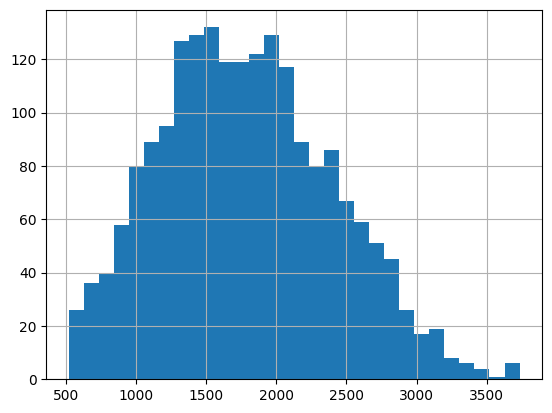

In [49]:
ref_df['Energy (kcal)'].hist(bins=30) 

### Grid plots

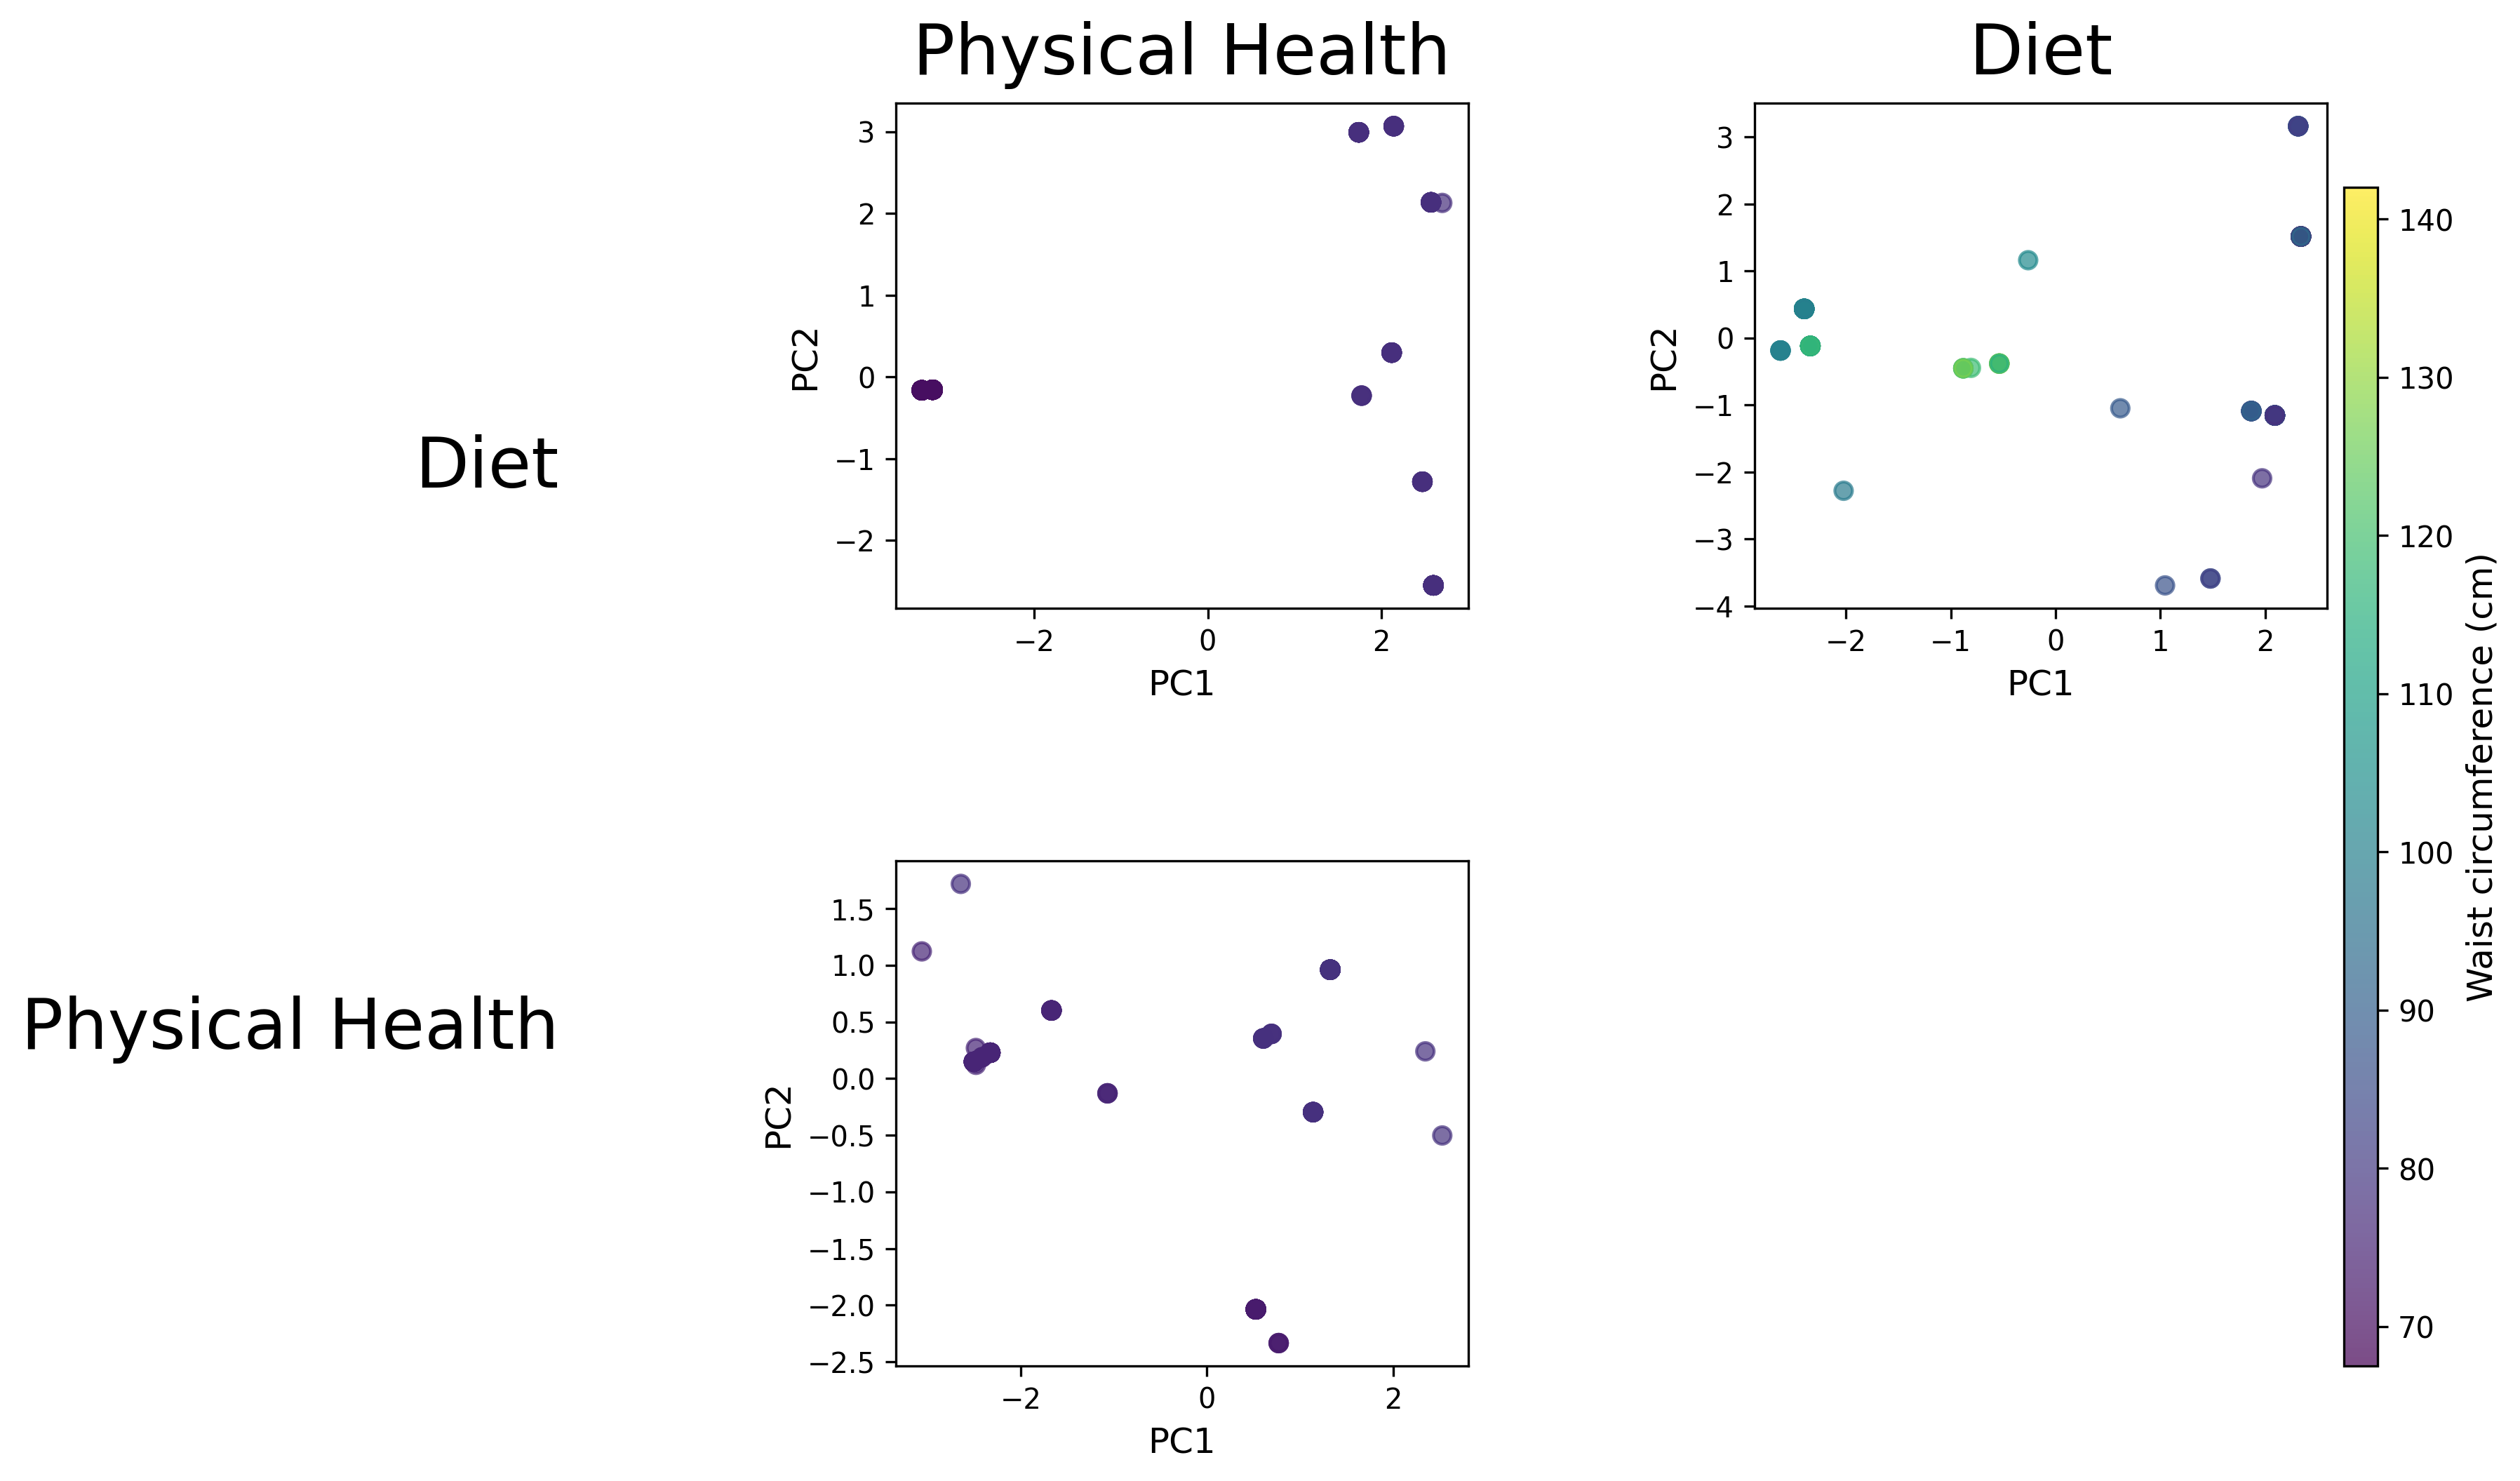

In [5]:
# Shared vmin/vmax for consistent colour scale across cells
MULTICAT=True

all_vals = []
for cell_key in cell_feature_sets:
    df = extract_cell_data(archive_data, cell_key)
    if color_feature in df.columns:
        all_vals.extend(df[color_feature].dropna().tolist())
vmin, vmax = min(all_vals), max(all_vals)

# PCA coloured by color_feature
fig_pca = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_counterfactuals,
    plot_type_name='PCA of Counterfactuals',
    color_feature=color_feature,
    global_vmin=vmin, global_vmax=vmax,
    wspace=0.5, figsize_per_cell=(4, 4), rowlabel_offset=-0.1,
    colorbar_label=color_feature, fontsize=12,
    colorbar=True, colorbar_fontsize=12, multicat=MULTICAT
)
plt.show()

# PCA coloured by cluster
figA = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_by_cluster,
    plot_type_name='PCA of Counterfactuals (clustered)',
    wspace=0.5, figsize_per_cell=(6, 6), rowlabel_fontsize=30, title_fontsize=30,
    cluster_method=cluster_method, reducer=reducer, max_k=max_k, fontsize=24, legend_pos='lower left', multicat=MULTICAT, rowlabel_offset=-0.1,
)
figA.savefig('PCA.png', bbox_inches='tight')

eta_2_threshold = 0.14 # Cohen's effect size convention for strong cluster differentiation

figB = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_cf_eta2_bar_cell,
    plot_type_name='η² for Mutable Features',
    figsize_per_cell=(3, 3.2), rowlabel_offset=-0.3, wspace=1.5, hspace=0.3,
    cluster_method=cluster_method, reducer=reducer, max_k=max_k, force_k=force_k, scaled=True, top_n=10,
    fontsize=16, threshold=eta_2_threshold, multicat=MULTICAT
)
figB.savefig('eta_mutable.png', bbox_inches='tight')

figC = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_cf_eta2_bar_constraints_cell,
    plot_type_name='η² for Constraint Features',
    figsize_per_cell=(4, 4.1), rowlabel_offset=-0.4, wspace=2, hspace=0.3,
    cluster_method=cluster_method, reducer=reducer, max_k=max_k, force_k=force_k, scaled=True, top_n=10,
    fontsize=20, threshold=eta_2_threshold, multicat=MULTICAT
)
figC.savefig('eta_constraint.png', bbox_inches='tight')

figD = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_cf_meanvalue_heatmap_cell,
    plot_type_name='Mutable',
    figsize_per_cell=(4, 3.75), cluster_method=cluster_method, reducer=reducer,
    rowlabel_offset=-0.2, max_k=max_k, force_k=force_k, scale=True, fontsize=14, multicat=MULTICAT
)
figD.savefig('grid_mutable.png', bbox_inches='tight')

figE = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_type_name='Constraint',
    figsize_per_cell=(4, 4.25), cluster_method=cluster_method, reducer=reducer,
    rowlabel_offset=-0.2, max_k=max_k, force_k=force_k, scale=True, fontsize=16, multicat=MULTICAT
)
figE.savefig('grid_constraint.png', bbox_inches='tight')

for fig in [figA, figB, figC, figD, figE]:
    plt.close(fig)


In [10]:
### η² numerical report — inspect close calls around the threshold
category_labels = list(feature_categories.keys())
num_categories  = len(category_labels)

for i in range(num_categories):
    for j in range(num_categories):
        cell_key = (i, j)
        df       = extract_cell_data(archive_data, cell_key)
        if df.empty:
            continue
        mutable = cell_feature_sets[cell_key]

        report_eta2(df, cell_key, mutable, cluster_method, reducer,
                    feature_type='mutable',
                    max_k=max_k, force_k=force_k, scaled=True,
                    threshold=eta_2_threshold)

        report_eta2(df, cell_key, mutable, cluster_method, reducer,
                    feature_type='constraint',
                    max_k=max_k, force_k=force_k, scaled=True,
                    threshold=eta_2_threshold)


η² report — Cell (0, 0) — mutable features  (k=3, n=200)
  Threshold : 0.140  (Cohen large effect)
  Stat. ref : 0.030  (α=0.05, F-distribution)
  Feature                                   η²          margin
  ────────────────────────────────────────────────────────────
  Waist circumference (cm)              0.9901       ✓  +0.8501
  Diastolic BP (mmHg)                   0.9779       ✓  +0.8379
  Total cholesterol (mg/dL)             0.8380       ✓  +0.6980
  Systolic BP (mmHg)                    0.7313       ✓  +0.5913

η² report — Cell (0, 0) — constraint features  (k=3, n=200)
  Threshold : 0.140  (Cohen large effect)
  Stat. ref : 0.030  (α=0.05, F-distribution)
  Feature                                   η²          margin
  ────────────────────────────────────────────────────────────
  Age (years)                           0.7720       ✓  +0.6320
  Total sugars (g)                      0.1222       ✗  -0.0178 ← close
  Poverty-income ratio                  0.0985       ✗  -0.041

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cell_key = (0, 0)
df_diag  = extract_cell_data(archive_data, cell_key)
mutable  = cell_feature_sets[cell_key]
X_diag   = StandardScaler().fit_transform(df_diag[mutable].values)

print(f"Silhouette scores — cell {cell_key}  (n={X_diag.shape[0]})")
scores = {}
for k in range(2, 30):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_diag)
    scores[k] = silhouette_score(X_diag, labels_k)
    print(f"  k={k:>2}: {scores[k]:.4f}")

best_k = max(scores, key=scores.get)
print(f"\nBest k by silhouette: {best_k}  (score={scores[best_k]:.4f})")
print(f"Forced k in analysis: {max_k}")


Silhouette scores — cell (0, 0)  (n=200)
  k= 2: 0.6293
  k= 3: 0.8063
  k= 4: 0.8614
  k= 5: 0.8665
  k= 6: 0.9034
  k= 7: 0.9112
  k= 8: 0.9284
  k= 9: 0.9381
  k=10: 0.9442
  k=11: 0.9429
  k=12: 0.9408
  k=13: 0.9469
  k=14: 0.9653
  k=15: 0.9692
  k=16: 0.9720
  k=17: 0.9700
  k=18: 0.9550


/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (19). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (18) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (21). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (22). Possibly due to duplicate points in X.
  return fit_method(estimato

  k=19: 0.9700
  k=20: 0.9550
  k=21: 0.9700
  k=22: 0.9700
  k=23: 0.9700


/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (24). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (25). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (26). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (27). Possibly due to duplicate points in X.
  return fit_method(estimato

  k=24: 0.9700
  k=25: 0.9700
  k=26: 0.9700
  k=27: 0.9700
  k=28: 0.9700
  k=29: 0.9700

Best k by silhouette: 16  (score=0.9720)
Forced k in analysis: 3


/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (28). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (29). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


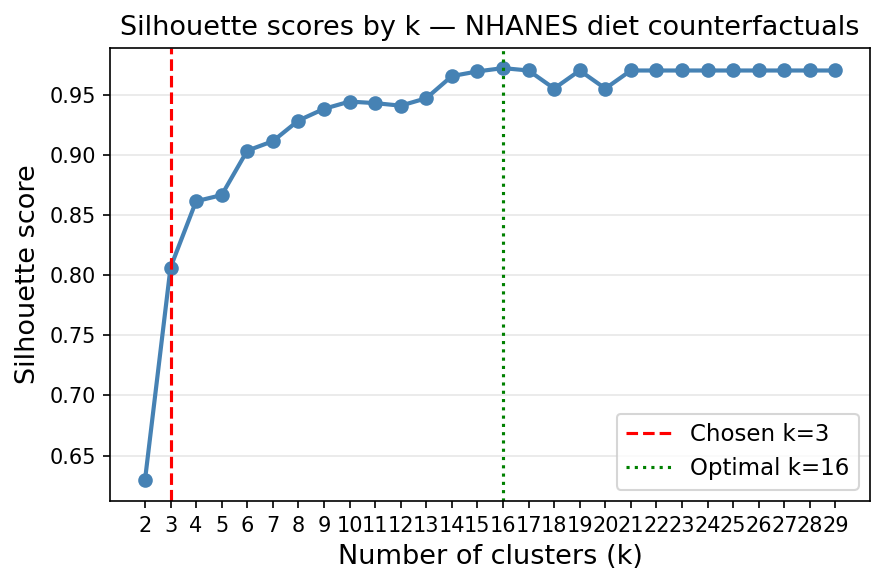

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ks = list(scores.keys())
sils = list(scores.values())

ax.plot(ks, sils, marker='o', linewidth=2, color='steelblue')
ax.axvline(max_k, color='red', linestyle='--', linewidth=1.5, label=f'Chosen k={max_k}')
ax.axvline(best_k, color='green', linestyle=':', linewidth=1.5, label=f'Optimal k={best_k}')
ax.set_xlabel('Number of clusters (k)', fontsize=13)
ax.set_ylabel('Silhouette score', fontsize=13)
ax.set_title('Silhouette scores by k — NHANES diet counterfactuals', fontsize=13)
ax.set_xticks(ks)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/silhouette_elbow.png', dpi=300, bbox_inches='tight')
plt.show()


#### Combined figure (A–E)

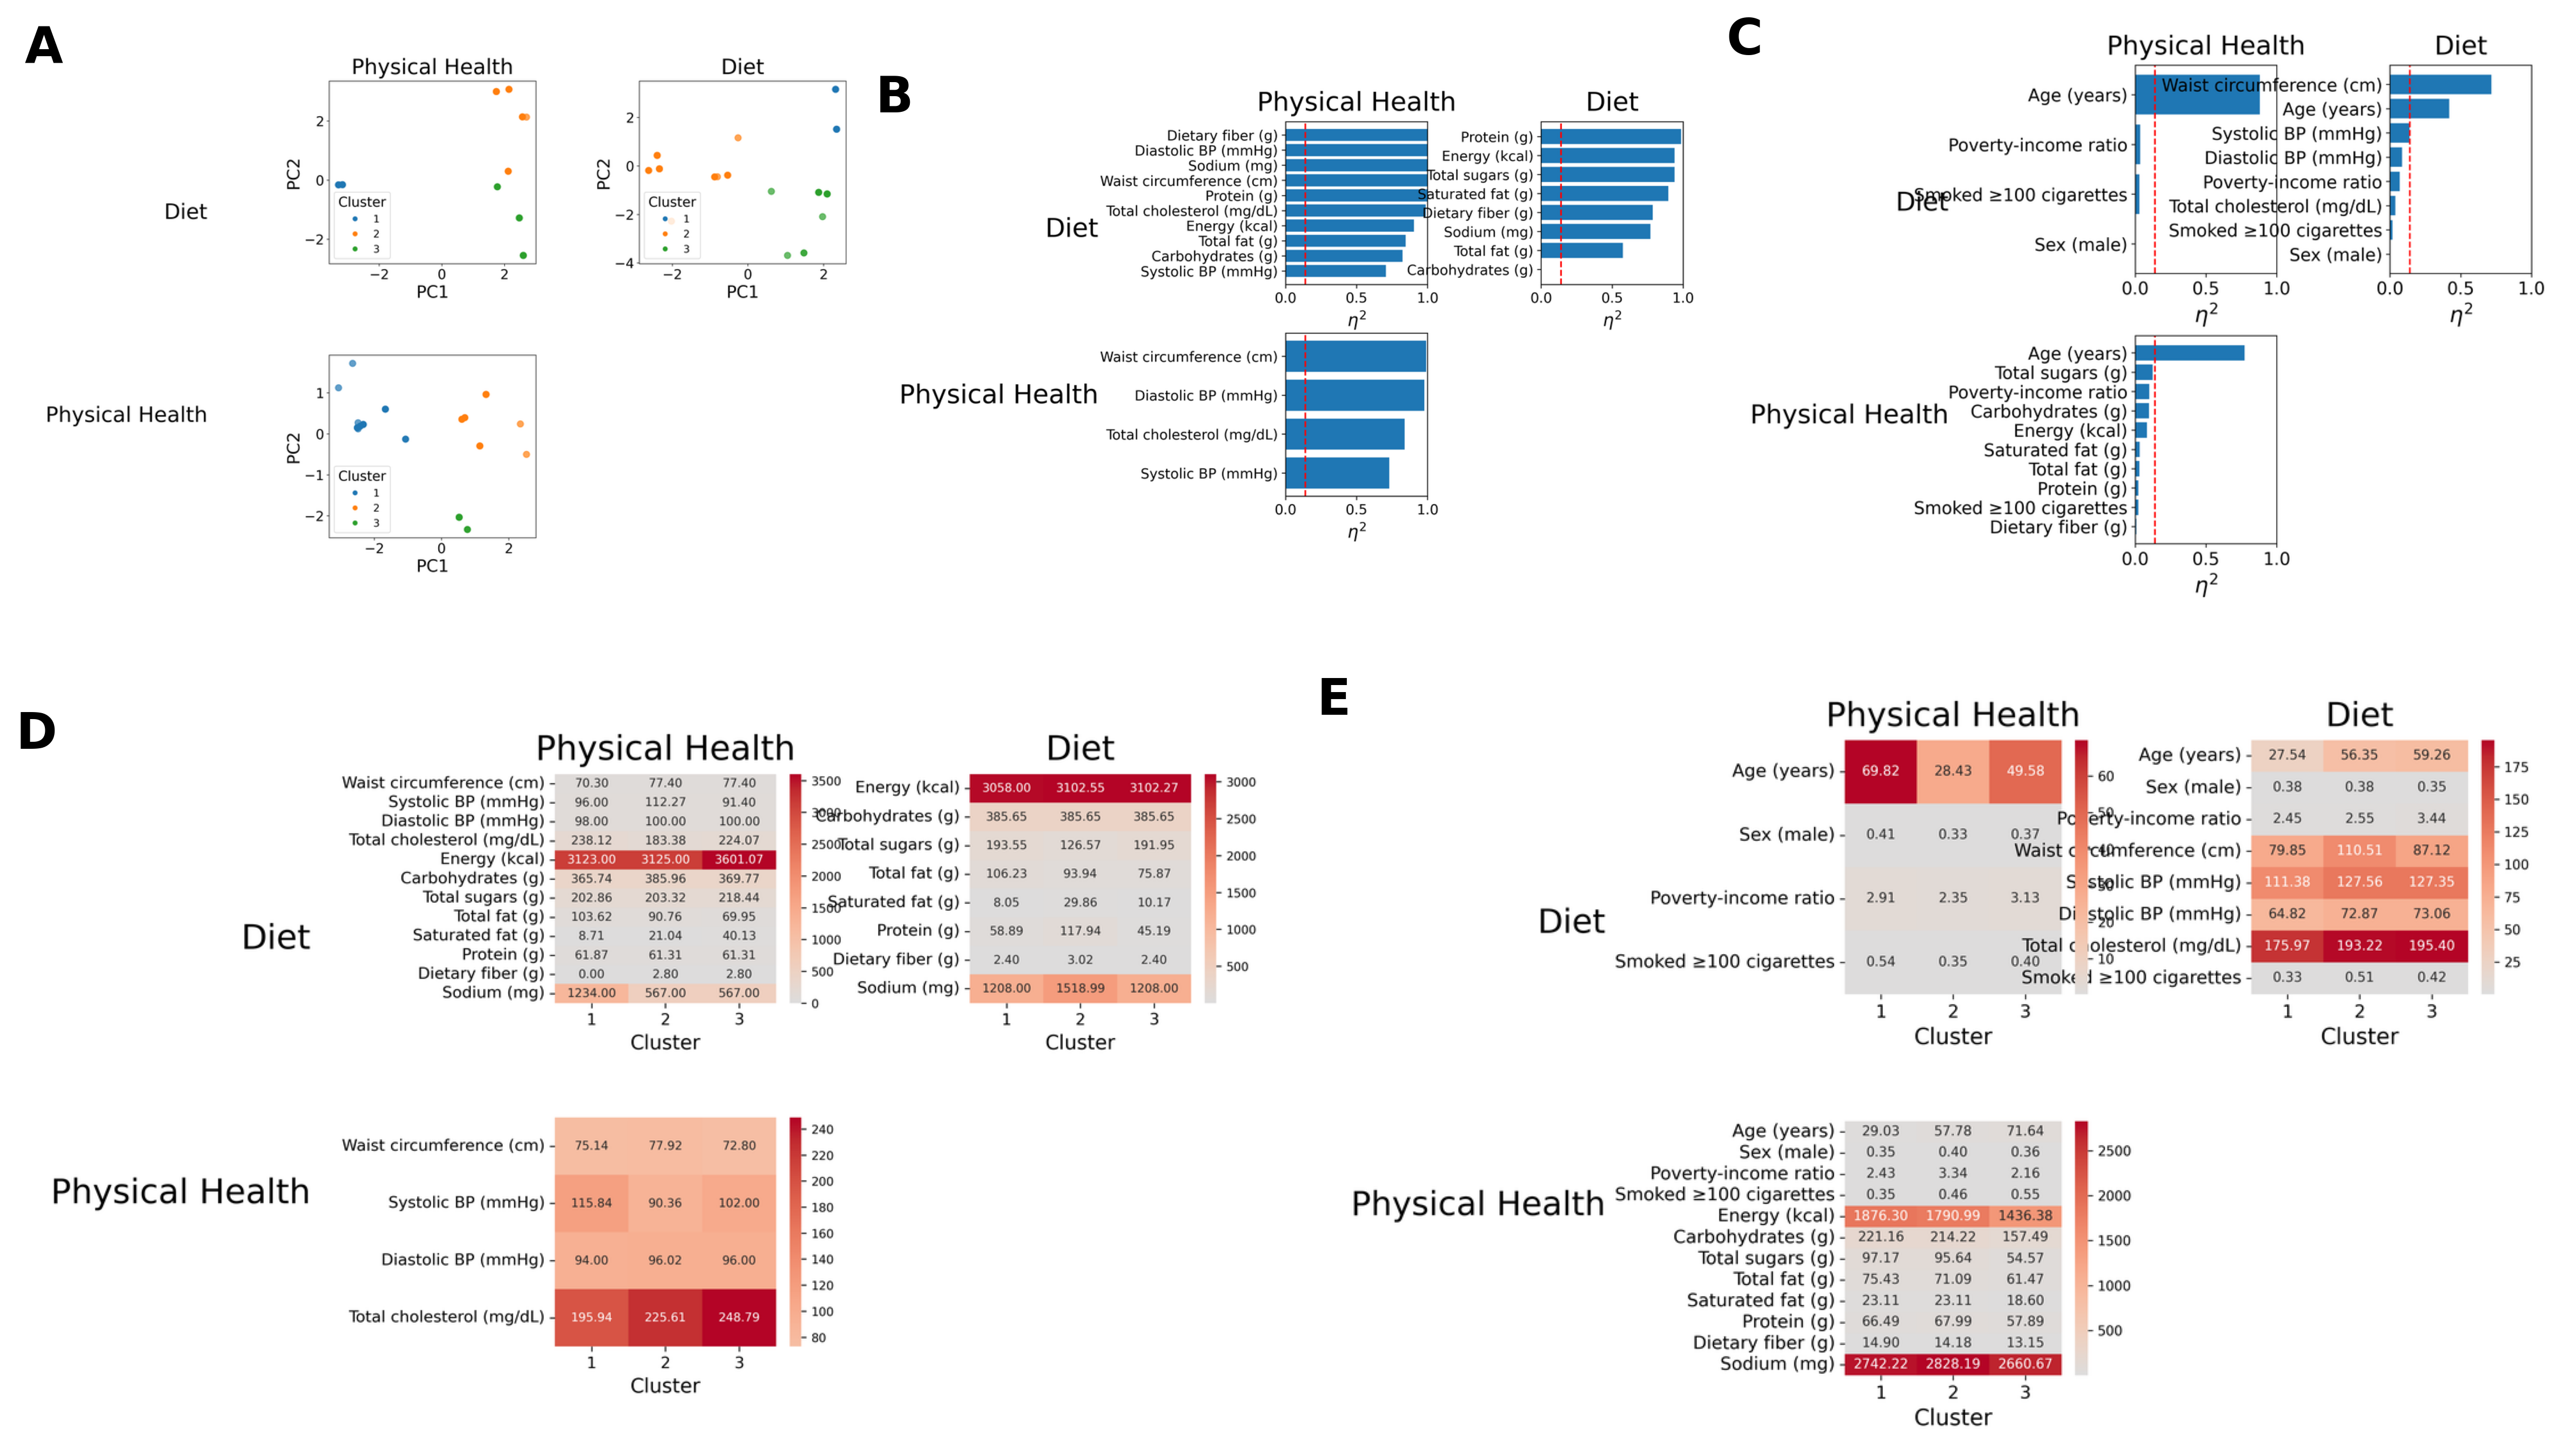

In [27]:
from matplotlib.gridspec import GridSpec
from PIL import Image
import numpy as np

def load_and_resize(path, target_height=600):
    img = Image.open(path)
    aspect = img.width / img.height
    new_width = int(target_height * aspect)
    return np.array(img.resize((new_width, target_height), Image.LANCZOS))

imgA = load_and_resize('PCA.png')
imgB = load_and_resize('eta_mutable.png')
imgC = load_and_resize('eta_constraint.png')
imgD = load_and_resize('grid_mutable.png')
imgE = load_and_resize('grid_constraint.png')

fig = plt.figure(figsize=(20, 12), dpi=300)
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.0, figure=fig)

gs_top = gs[0].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.05)
axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[0, 1])
axC = fig.add_subplot(gs_top[0, 2])

gs_bot = gs[1].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.05)
axD = fig.add_subplot(gs_bot[0, 0])
axE = fig.add_subplot(gs_bot[0, 1])

for ax, img in zip([axA, axB, axC, axD, axE], [imgA, imgB, imgC, imgD, imgE]):
    ax.imshow(img)
    ax.axis('off')

# ── Per-panel label positions (x, y in axes coordinates) ─────────────────────
# Adjust each tuple independently to nudge a label without affecting the others.
label_positions = {
    'A': (-0.02, 1.055),
    'B': (-0.02, 1.02),
    'C': (-0.02, 1.02),
    'D': (-0.02, 1.02),
    'E': (-0.02, 1.02),
}

axes_map = {'A': axA, 'B': axB, 'C': axC, 'D': axD, 'E': axE}
for lbl, ax in axes_map.items():
    x, y = label_positions[lbl]
    ax.text(x, y, lbl, transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')

plt.savefig(f'{output_dir}/figure_xgb_nhanes.png', bbox_inches='tight', dpi=300)
plt.show()

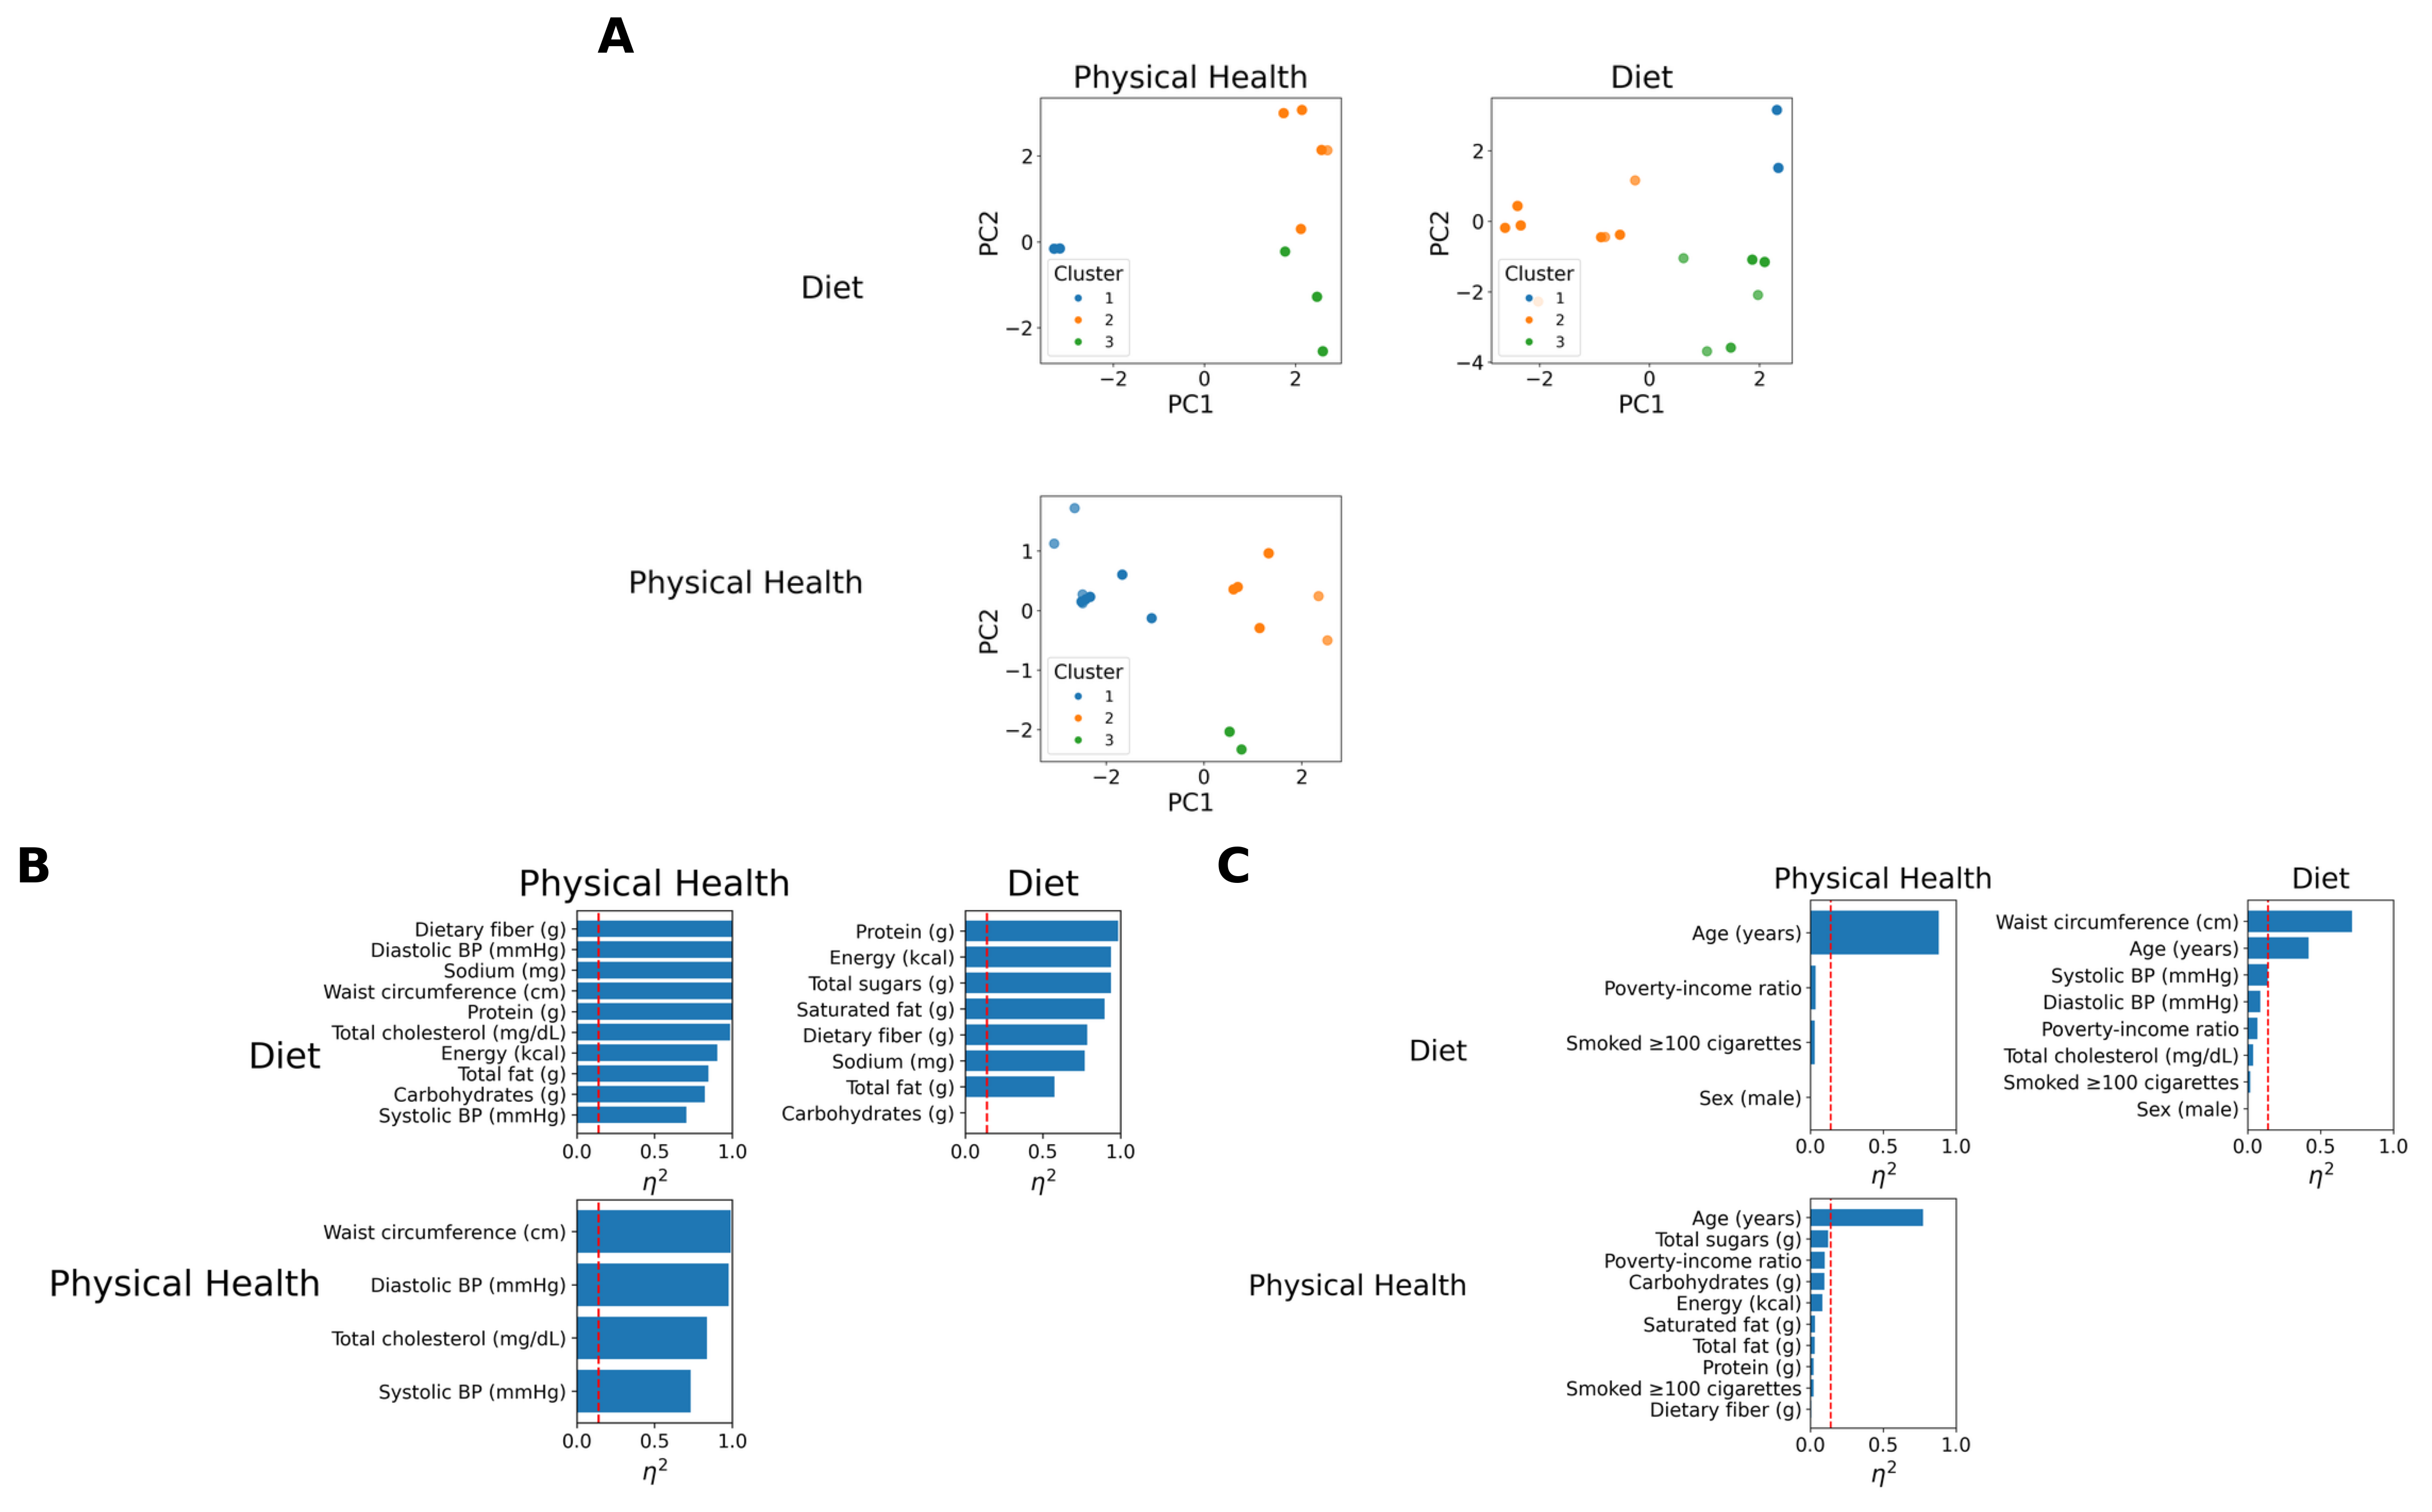

In [35]:
from matplotlib.gridspec import GridSpec
from PIL import Image
import numpy as np

def load_and_resize(path, target_height=600):
    img = Image.open(path)
    aspect = img.width / img.height
    new_width = int(target_height * aspect)
    return np.array(img.resize((new_width, target_height), Image.LANCZOS))

imgA = load_and_resize('PCA.png')
imgB = load_and_resize('eta_mutable.png')
imgC = load_and_resize('eta_constraint.png')

fig = plt.figure(figsize=(20, 12), dpi=300)
gs = GridSpec(2, 1, height_ratios=[1.2, 1], hspace=0.05, figure=fig)

gs_top = gs[0].subgridspec(1, 1)
axA = fig.add_subplot(gs_top[0, 0])

gs_bot = gs[1].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.05)
axB = fig.add_subplot(gs_bot[0, 0])
axC = fig.add_subplot(gs_bot[0, 1])

for ax, img in zip([axA, axB, axC], [imgA, imgB, imgC]):
    ax.imshow(img)
    ax.axis('off')

label_positions = {
    'A': (-0.02, 1.055),
    'B': (-0.02, 1.02),
    'C': (-0.02, 1.02),
}

axes_map = {'A': axA, 'B': axB, 'C': axC}
for lbl, ax in axes_map.items():
    x, y = label_positions[lbl]
    ax.text(x, y, lbl, transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')

plt.savefig(f'{output_dir}/figure_xgb_nhanes.png', bbox_inches='tight', dpi=300)
plt.show()

### Decision tree (constraint → cluster)

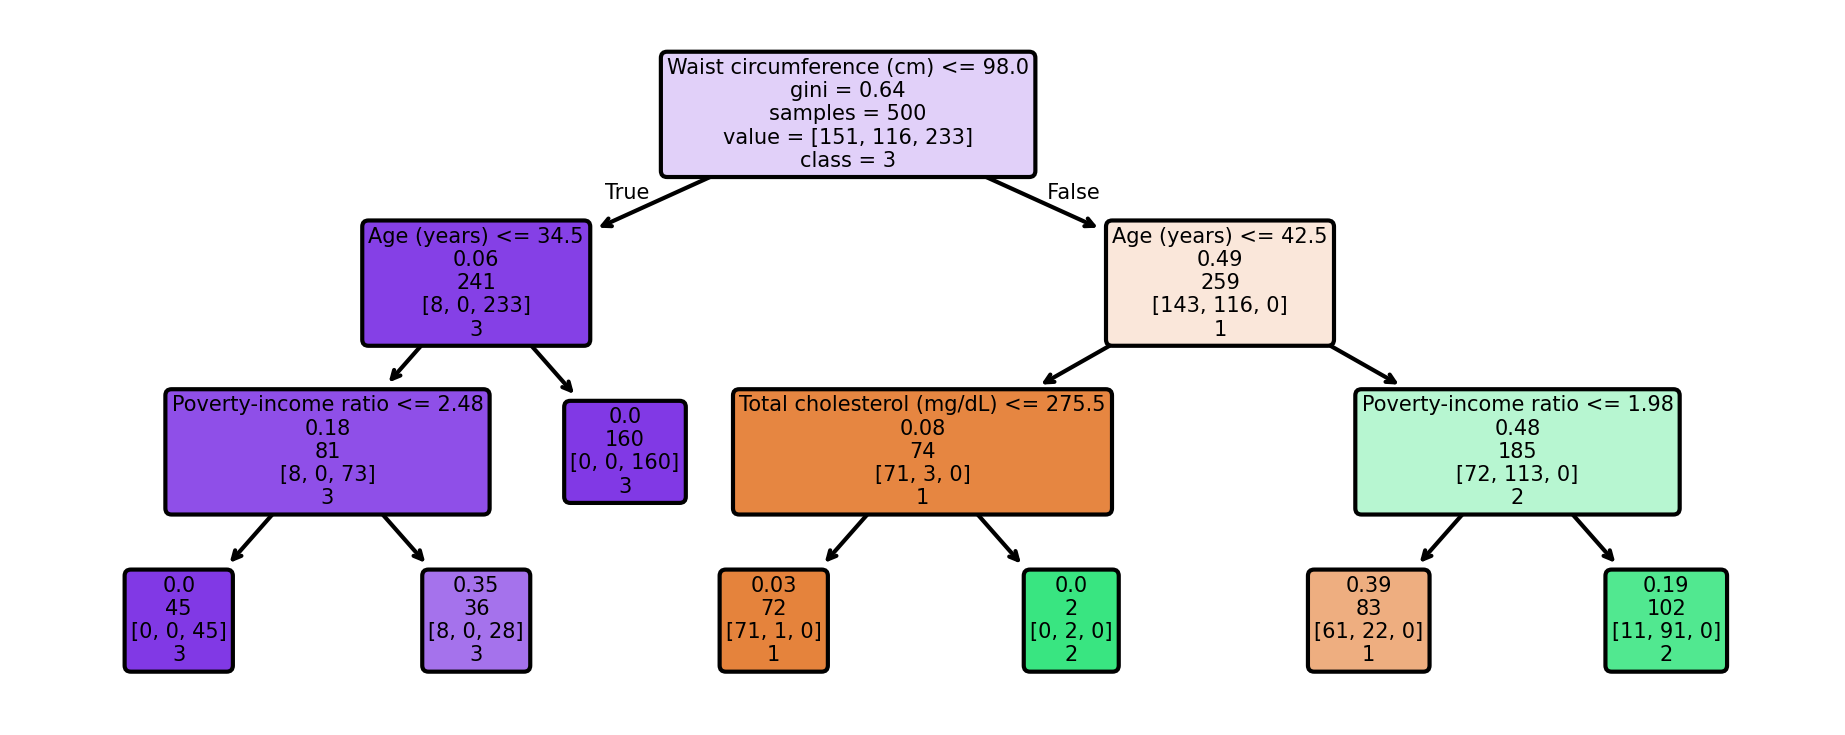

In [20]:
fig = plot_cellwise_grid(
    archive_data, cell_feature_sets, feature_categories,
    tree_constraints_to_cluster_kmeans,
    figsize_per_cell=(7, 3), hspace=0.1, wspace=0.2, max_depth=3, max_k=3
)
plt.show()

### Similarity network

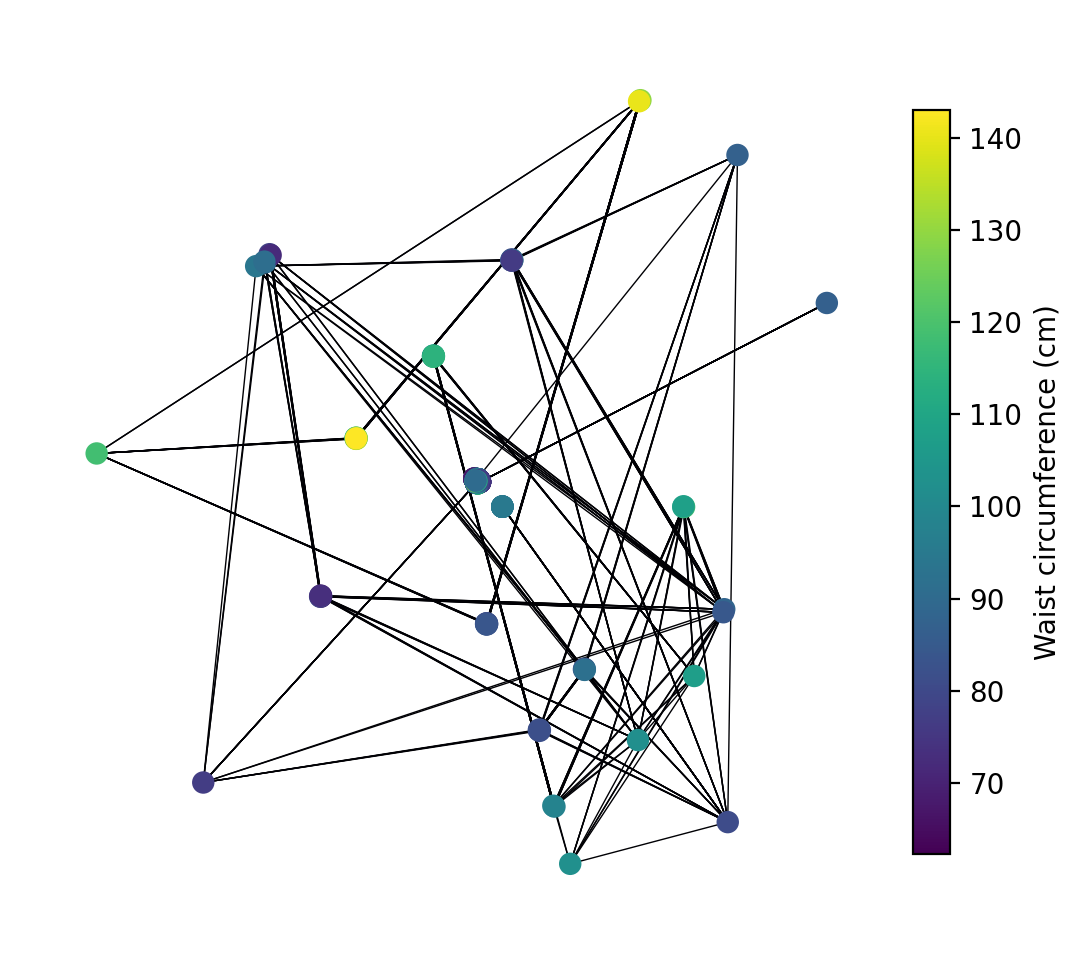

Saved similarity network.


In [ ]:
color_feature = 'Waist circumference (cm)'
G, edge_index, edge_weights, edge_attr, fused_affinity = get_similarity(
    archive_data, cell_feature_sets, feature_categories,
    ref_df, color_feature=color_feature, K=30, mu=0.5
)

pos = nx.spring_layout(G, seed=42, weight='weight', iterations=300)
ew_norm = (edge_weights - edge_weights.min()) / (edge_weights.ptp() + 1e-12)
vals = np.array([d['value'] for _, d in G.nodes(data=True)])
vmin, vmax = np.nanmin(vals), np.nanmax(vals)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.set_axis_off()
nx.draw(G, pos, ax=ax, with_labels=False,
        node_color=vals, cmap='viridis', vmin=vmin, vmax=vmax,
        node_size=50,
        edge_color=[plt.cm.inferno(x) for x in ew_norm],
        width=0.5 + 1.5 * ew_norm)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array(vals)
cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.01)
cbar.set_label(color_feature, fontsize=10)
plt.show()

for u, v, d in G.edges(data=True):
    d['weight'] = float(d['weight'])
nx.write_graphml(G, f'{output_dir}/similarity_network_xgb_nhanes.graphml')
print('Saved similarity network.')

In [12]:
cell_df = extract_cell_data(archive_data, (0, 0))

### SHAP analysis (TreeExplainer)

/tmp/ipykernel_3956554/813122906.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_shap, plot_type='dot', max_display=20)


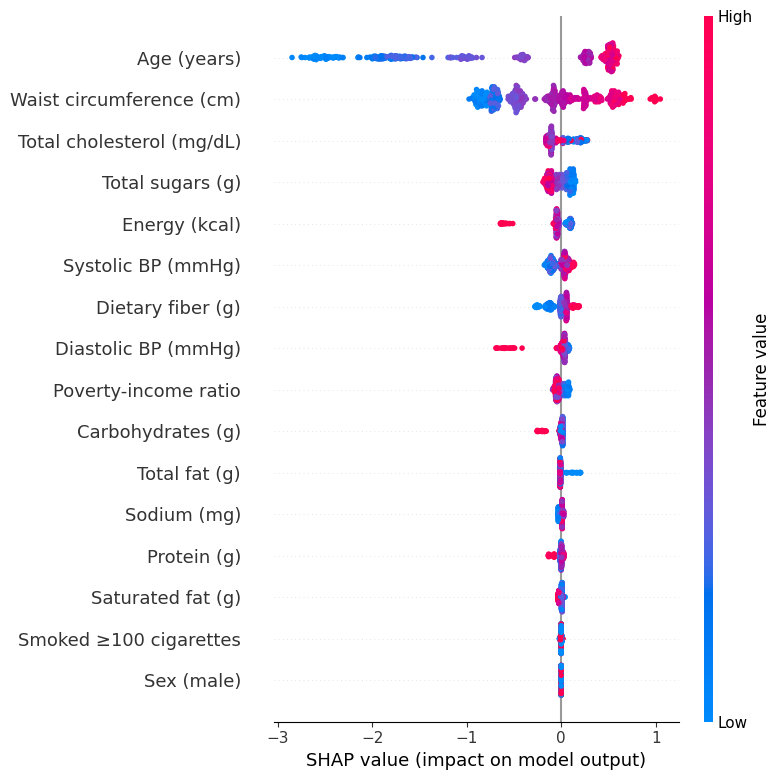

In [ ]:
import shap

model_path   = os.path.expanduser('~/models/xgb_nhanes_diet.pkl')
X_test_full  = pd.read_csv(os.path.expanduser('~/MAP-CF/real/X_test_xgb_nhanes_diet.csv'))

# Align to the same individuals used in run_coala (keyed by row index)
ALIGN = True
if ALIGN:
    coala_ids   = sorted(archive_data.keys())
    X_test_shap = X_test_full.iloc[coala_ids].reset_index(drop=True)
else:
    # option to not use coala_ids and just use the full test set for SHAP — IGNORE --- 
    X_test_shap = X_test_full.reset_index(drop=True)


with open(model_path, 'rb') as f:
    xgb_model = pickle.load(f)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

shap.summary_plot(shap_values, X_test_shap, plot_type='dot', max_display=20)

/tmp/ipykernel_2022553/983887116.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_shap, plot_type='bar', max_display=16)


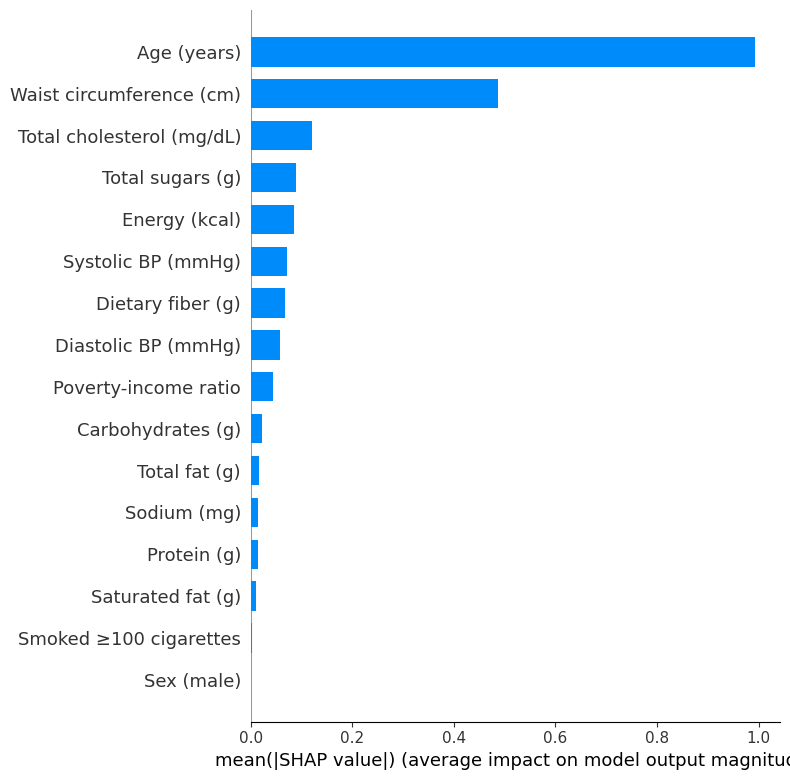

In [58]:
shap.summary_plot(shap_values, X_test_shap, plot_type='bar', max_display=16)

### SHAP Clustering

In [4]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import f as f_dist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
import seaborn as sns


def shap_optimal_hclust_k(X, max_k=10, force_k=None, min_cluster_frac=0.05):
    """
    min_cluster_frac: reject any k where the smallest cluster is smaller than
    this fraction of total samples — prevents degenerate outlier-only clusters
    from winning on silhouette score.
    """
    Z = linkage(X, method='ward', metric='euclidean')
    if force_k is not None:
        labels = fcluster(Z, t=force_k, criterion='maxclust')
        return force_k, labels, Z
    best_score, best_k, best_labels = -1, None, None
    min_size = max(2, int(min_cluster_frac * X.shape[0]))
    for k in range(2, max_k + 1):
        labels = fcluster(Z, t=k, criterion='maxclust')
        if len(np.unique(labels)) < 2:
            continue
        counts = np.bincount(labels)[1:]   # labels start at 1
        if counts.min() < min_size:
            print(f'k={k}: skipped (smallest cluster = {counts.min()} < {min_size})')
            continue
        score = silhouette_score(X, labels, metric='euclidean')
        print(f'k={k}: silhouette={score:.4f}  cluster sizes={sorted(counts.tolist())}')
        if score > best_score:
            best_score, best_k, best_labels = score, k, labels
    return best_k, best_labels, Z


def shap_eta2_threshold(alpha, n_samples, n_clusters):
    dfb, dfw = n_clusters - 1, n_samples - n_clusters
    if dfb <= 0 or dfw <= 0:
        return 1.0
    f_crit = f_dist.ppf(1 - alpha, dfb, dfw)
    return (f_crit * dfb) / (f_crit * dfb + dfw)

# SHAP clustering config
shap_max_k         = 10
shap_force_k       = 3   # force k=3 to match COALA; set None for silhouette-based
shap_top_n         = 10
shap_color_feature = 'Waist circumference (cm)'

# Mutable vs constraint split — derived from feature_categories so it is always
# consistent with what COALA treats as mutable/constraint.
mutable_features    = list({f for feats in feature_categories.values() for f in feats})
constraint_features = [c for c in X_test_shap.columns if c not in mutable_features]
print(f"Mutable  ({len(mutable_features)}): {mutable_features}")
print(f"Constraint ({len(constraint_features)}): {constraint_features}")

Mutable  (8): ['Protein (g)', 'Dietary fiber (g)', 'Sodium (mg)', 'Total sugars (g)', 'Saturated fat (g)', 'Energy (kcal)', 'Total fat (g)', 'Carbohydrates (g)']
Constraint (8): ['Age (years)', 'Sex (male)', 'Poverty-income ratio', 'Waist circumference (cm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 'Total cholesterol (mg/dL)', 'Smoked ≥100 cigarettes']


Best k: 3


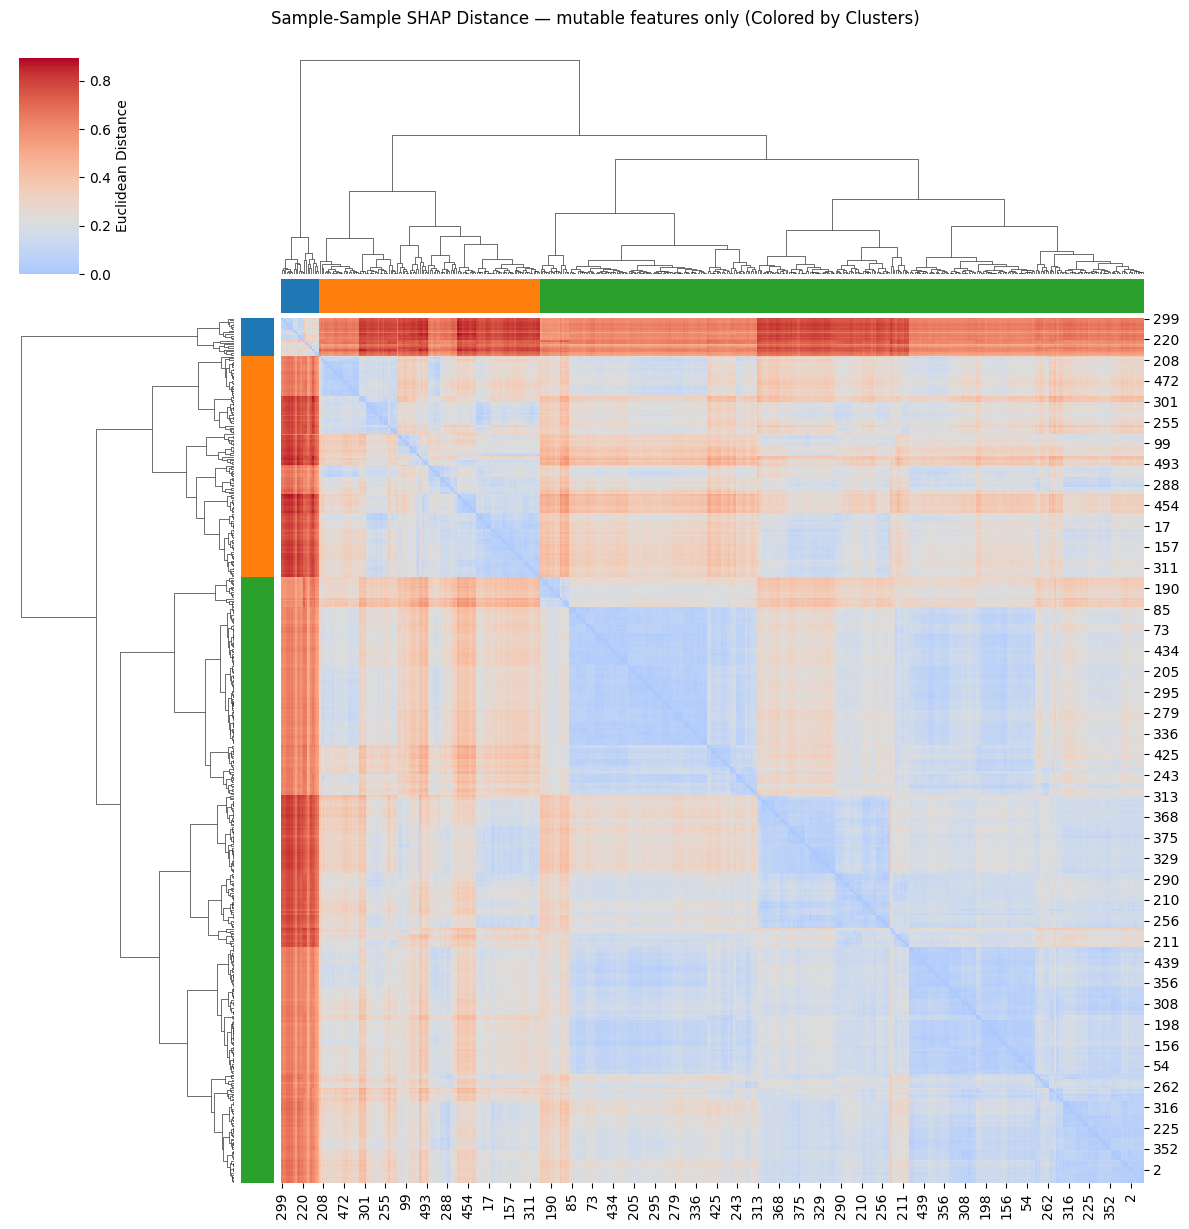

In [10]:
feature_names = X_test_shap.columns.tolist()
mutable_idx   = [feature_names.index(f) for f in mutable_features if f in feature_names]

# Cluster on mutable-feature SHAP values only.
# COALA clusters counterfactuals in the mutable feature space; doing the same
# here with SHAP makes every downstream metric (silhouette, DB, CH,
# constraint_accuracy) directly comparable between the two methods.
shap_values_mutable = shap_values[:, mutable_idx]

best_k_shap, cluster_labels_shap, Z_shap = shap_optimal_hclust_k(
    shap_values_mutable, max_k=shap_max_k, force_k=shap_force_k, min_cluster_frac=0.01
)
print(f'Best k: {best_k_shap}')

n_clusters_shap = len(np.unique(cluster_labels_shap))
palette_shap = sns.color_palette('tab10', n_clusters_shap)
cluster_color_map = dict(zip(np.unique(cluster_labels_shap), palette_shap))
row_colors_shap = pd.Series(cluster_labels_shap).map(cluster_color_map).to_numpy()

pairwise_dist = squareform(pdist(shap_values_mutable, metric='euclidean'))

g = sns.clustermap(
    pairwise_dist,
    row_linkage=Z_shap, col_linkage=Z_shap,
    row_colors=row_colors_shap, col_colors=row_colors_shap,
    cmap='coolwarm', center=np.median(pairwise_dist),
    figsize=(12, 12),
    cbar_kws={'label': 'Euclidean Distance'},
)
g.fig.suptitle('Sample-Sample SHAP Distance — mutable features only (Colored by Clusters)', y=1.02)
plt.show()


/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [1] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/global/home/hpc5434/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


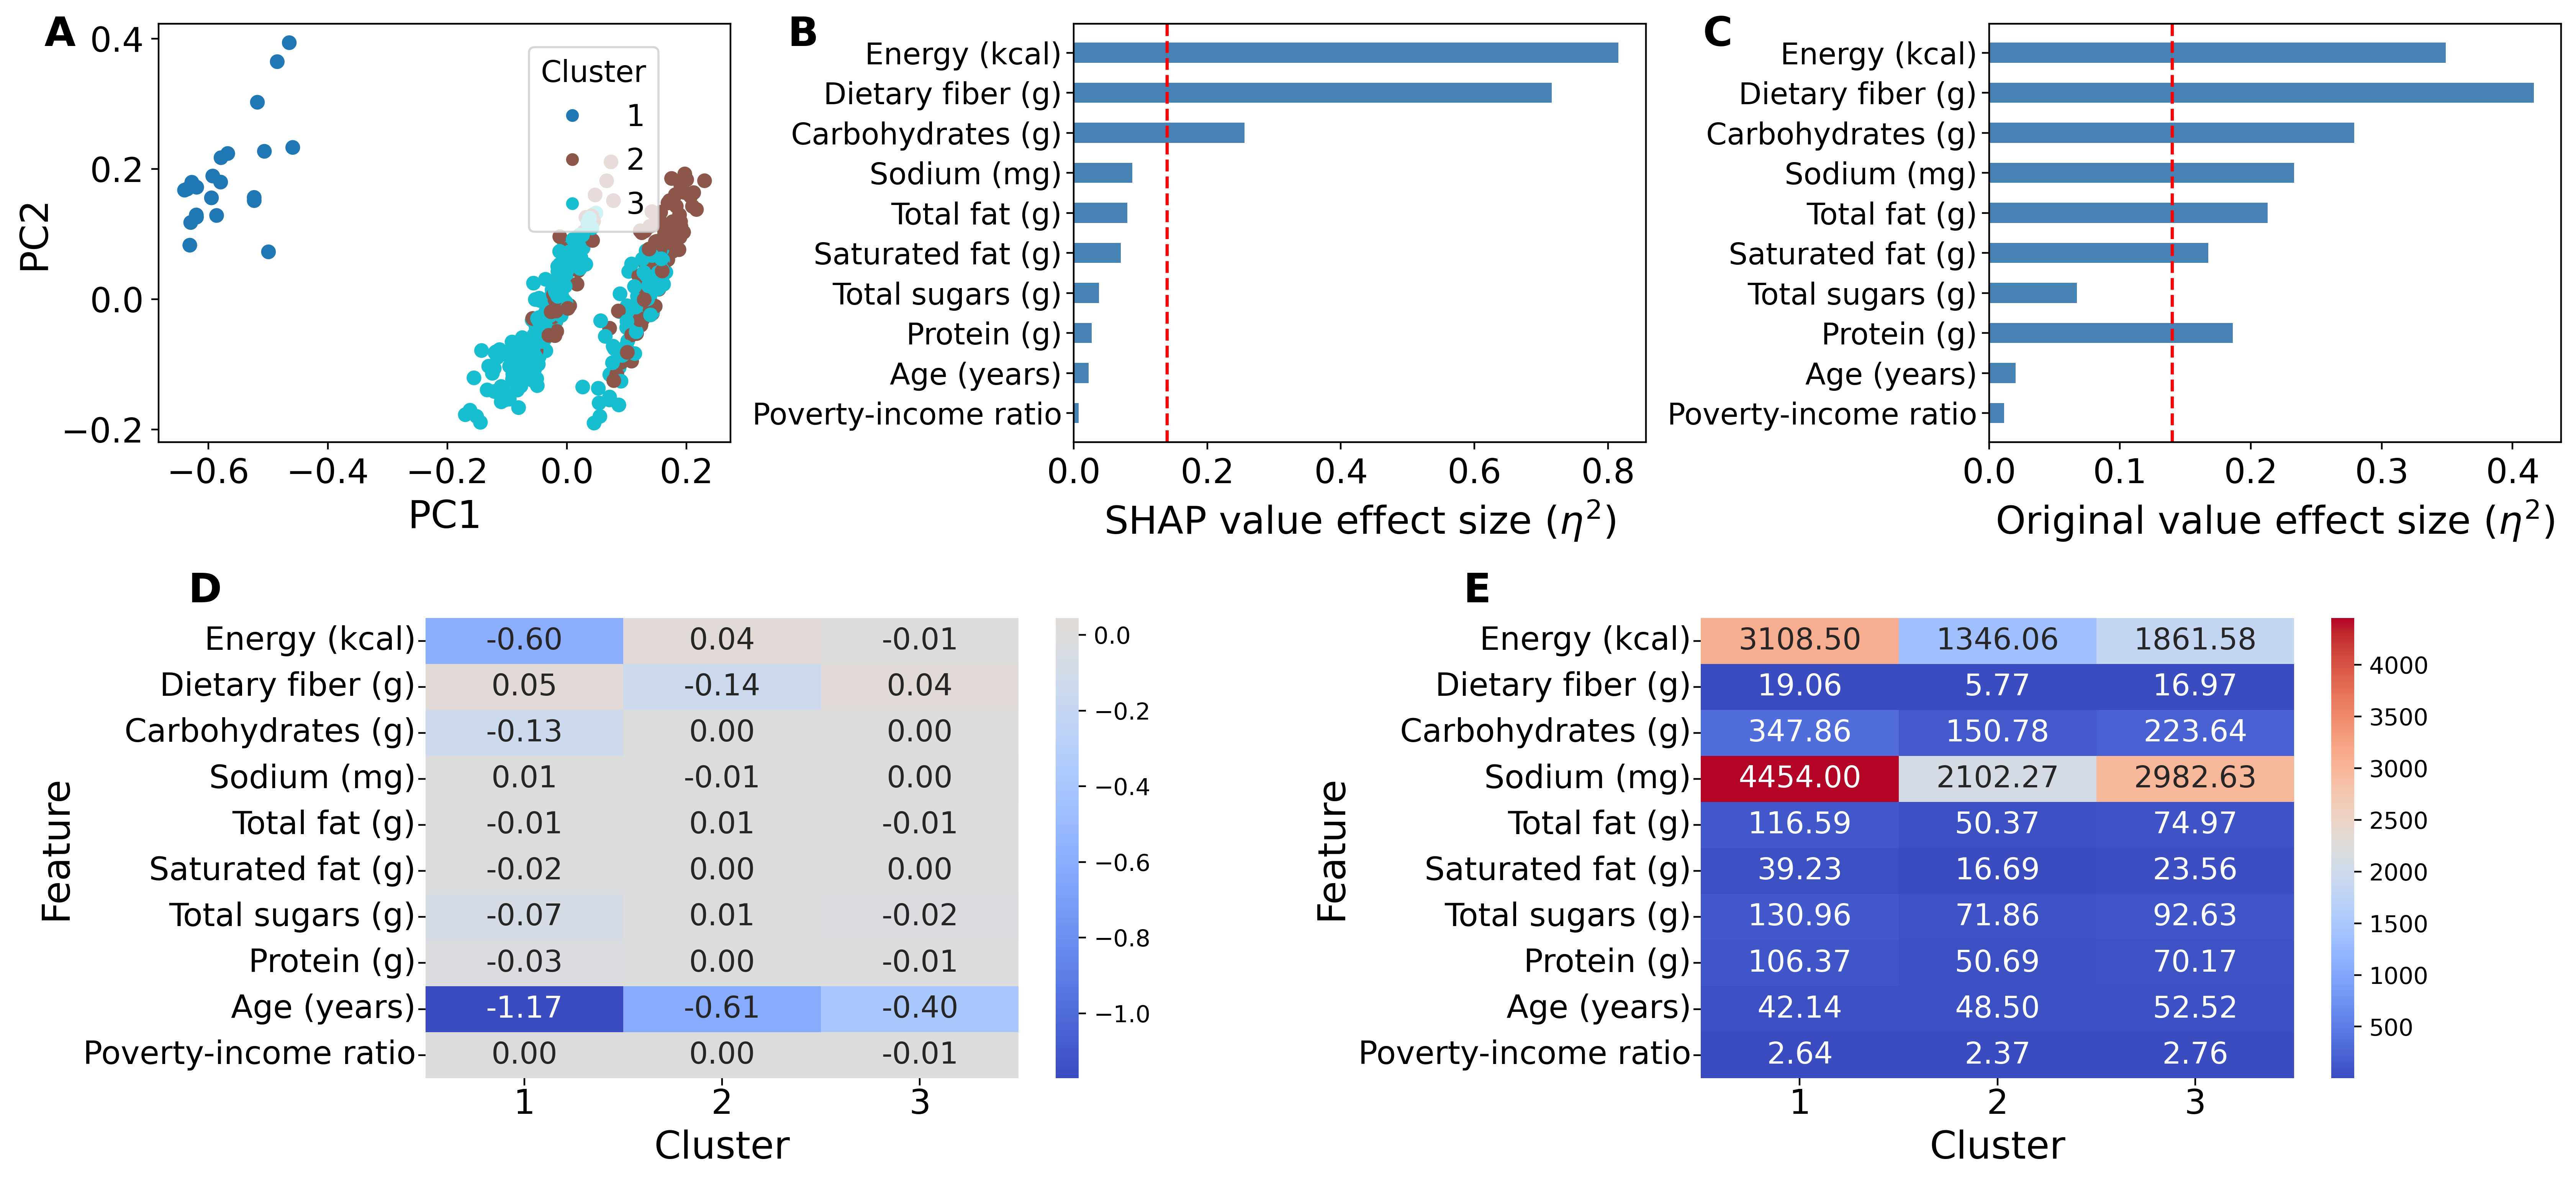

In [11]:
# PCA visualises the mutable-SHAP space that the clustering was performed in
shap_pca = PCA(n_components=2).fit_transform(shap_values_mutable)

n_shap_samples   = shap_values_mutable.shape[0]
eta2_thresh_shap = 0.14 #shap_eta2_threshold(0.05, n_shap_samples, n_clusters_shap)

dfb = n_clusters_shap - 1
dfw = n_shap_samples - n_clusters_shap

# η² computed over ALL features (mutable + constraint) so the bar plot reveals
# whether constraint SHAP values also discriminate clusters formed in mutable space.
F_shap, _ = f_classif(shap_values, cluster_labels_shap)
eta2_shap_vals = (F_shap * dfb) / (F_shap * dfb + dfw)

F_raw, _ = f_classif(X_test_shap, cluster_labels_shap)
eta2_raw_vals = (F_raw * dfb) / (F_raw * dfb + dfw)

sorted_idx     = np.argsort(-eta2_shap_vals)
top_feats      = np.array(feature_names)[sorted_idx][:shap_top_n]
top_eta2_shap  = eta2_shap_vals[sorted_idx][:shap_top_n]
top_eta2_raw   = eta2_raw_vals[sorted_idx][:shap_top_n]

cluster_df_shap              = pd.DataFrame(shap_values, columns=feature_names)
cluster_df_shap['cluster']   = cluster_labels_shap
mean_shap_by_cluster         = cluster_df_shap.groupby('cluster').mean()

X_with_cluster               = X_test_shap.copy()
X_with_cluster['cluster']    = cluster_labels_shap
mean_raw_by_cluster          = X_with_cluster.groupby('cluster').mean()

def fmt_heatmap(df, decimals=2, zero_tol=5e-3):
    arr = df.to_numpy().copy()
    arr[np.abs(arr) < zero_tol] = 0.0
    return np.vectorize(lambda x: f'{x:.{decimals}f}')(arr)

subplot_label_fs = 19; axis_label_fs = 18; tick_fs = 16; legend_fs = 14; hm_annot_fs = 14

fig = plt.figure(figsize=(16, 8), dpi=400)
outer     = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.1], hspace=0.4)
top_gs    = outer[0].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.6)
bottom_gs = outer[1].subgridspec(1, 5, width_ratios=[0.3, 1, 0.6, 1, 0.1], wspace=0.1)

# Panel A — PCA coloured by cluster (mutable SHAP space)
ax0 = fig.add_subplot(top_gs[0, 0])
sc = ax0.scatter(shap_pca[:, 0], shap_pca[:, 1], c=cluster_labels_shap, cmap='tab10', s=35)
ax0.set_xlabel('PC1', fontsize=axis_label_fs)
ax0.set_ylabel('PC2', fontsize=axis_label_fs)
ax0.tick_params(labelsize=tick_fs)
handles = [plt.Line2D([], [], marker='o', linestyle='',
           color=sc.cmap(sc.norm(i)), label=str(i), markersize=5)
           for i in np.unique(cluster_labels_shap)]
ax0.legend(handles=handles, title='Cluster', bbox_to_anchor=(0.9, 0.98),
           loc='upper right', fontsize=legend_fs, title_fontsize=legend_fs, frameon=True)
ax0.text(-0.20, 1.02, 'A', transform=ax0.transAxes,
         fontsize=subplot_label_fs, fontweight='bold', va='top')

# Panel B — SHAP η²
ax1 = fig.add_subplot(top_gs[0, 1])
ax1.barh(top_feats, top_eta2_shap, color='steelblue', height=0.5)
ax1.axvline(eta2_thresh_shap, linestyle='dashed', color='red', linewidth=1.5)
ax1.set_xlabel(r'SHAP value effect size ($\eta^2$)', fontsize=axis_label_fs)
ax1.tick_params(axis='x', labelsize=tick_fs)
ax1.tick_params(axis='y', labelsize=tick_fs - 2, pad=2)
ax1.invert_yaxis()
ax1.text(-0.50, 1.02, 'B', transform=ax1.transAxes,
         fontsize=subplot_label_fs, fontweight='bold', va='top')

# Panel C — raw η²
ax2 = fig.add_subplot(top_gs[0, 2])
ax2.barh(top_feats, top_eta2_raw, color='steelblue', height=0.5)
ax2.axvline(eta2_thresh_shap, linestyle='dashed', color='red', linewidth=1.5)
ax2.set_xlabel(r'Original value effect size ($\eta^2$)', fontsize=axis_label_fs)
ax2.tick_params(axis='x', labelsize=tick_fs)
ax2.tick_params(axis='y', labelsize=tick_fs - 2, pad=2)
ax2.invert_yaxis()
ax2.text(-0.50, 1.02, 'C', transform=ax2.transAxes,
         fontsize=subplot_label_fs, fontweight='bold', va='top')

heatmap_shap = mean_shap_by_cluster[top_feats].T
heatmap_raw  = mean_raw_by_cluster[top_feats].T

# Panel D — mean SHAP per cluster
ax3 = fig.add_subplot(bottom_gs[0, 1])
hm3 = sns.heatmap(heatmap_shap, cmap='coolwarm', center=0,
                  annot=fmt_heatmap(heatmap_shap), fmt='', ax=ax3,
                  annot_kws={'size': hm_annot_fs}, cbar_kws={'shrink': 1.0})
ax3.set_xlabel('Cluster', fontsize=axis_label_fs)
ax3.set_ylabel('Feature', fontsize=axis_label_fs)
ax3.tick_params(axis='x', labelsize=tick_fs, pad=1)
ax3.tick_params(axis='y', labelsize=tick_fs-1, pad=1)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)
ax3.text(-0.40, 1.1, 'D', transform=ax3.transAxes,
         fontsize=subplot_label_fs, fontweight='bold', va='top')
hm3.collections[0].colorbar.ax.tick_params(labelsize=11)

# Panel E — mean raw values per cluster
ax4 = fig.add_subplot(bottom_gs[0, 3])
hm4 = sns.heatmap(heatmap_raw, cmap='coolwarm',
                  annot=fmt_heatmap(heatmap_raw), fmt='', ax=ax4,
                  annot_kws={'size': hm_annot_fs}, cbar_kws={'shrink': 1.0})
ax4.set_xlabel('Cluster', fontsize=axis_label_fs)
ax4.set_ylabel('Feature', fontsize=axis_label_fs)
ax4.tick_params(axis='x', labelsize=tick_fs, pad=1)
ax4.tick_params(axis='y', labelsize=tick_fs-1, pad=1)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0)
ax4.text(-0.40, 1.1, 'E', transform=ax4.transAxes,
         fontsize=subplot_label_fs, fontweight='bold', va='top')
hm4.collections[0].colorbar.ax.tick_params(labelsize=11)

fig.subplots_adjust(left=0.0, right=0.98, top=0.96, bottom=0.10)
fig.savefig(f'{output_dir}/shap_cluster_panels.png', dpi=600, bbox_inches='tight')
plt.show()


In [8]:
# count how many are 1 and 2 for cluster_labels_shap
from collections import Counter
cluster_counts = Counter(cluster_labels_shap)
print(cluster_counts)

Counter({3: 277, 1: 158, 2: 65})


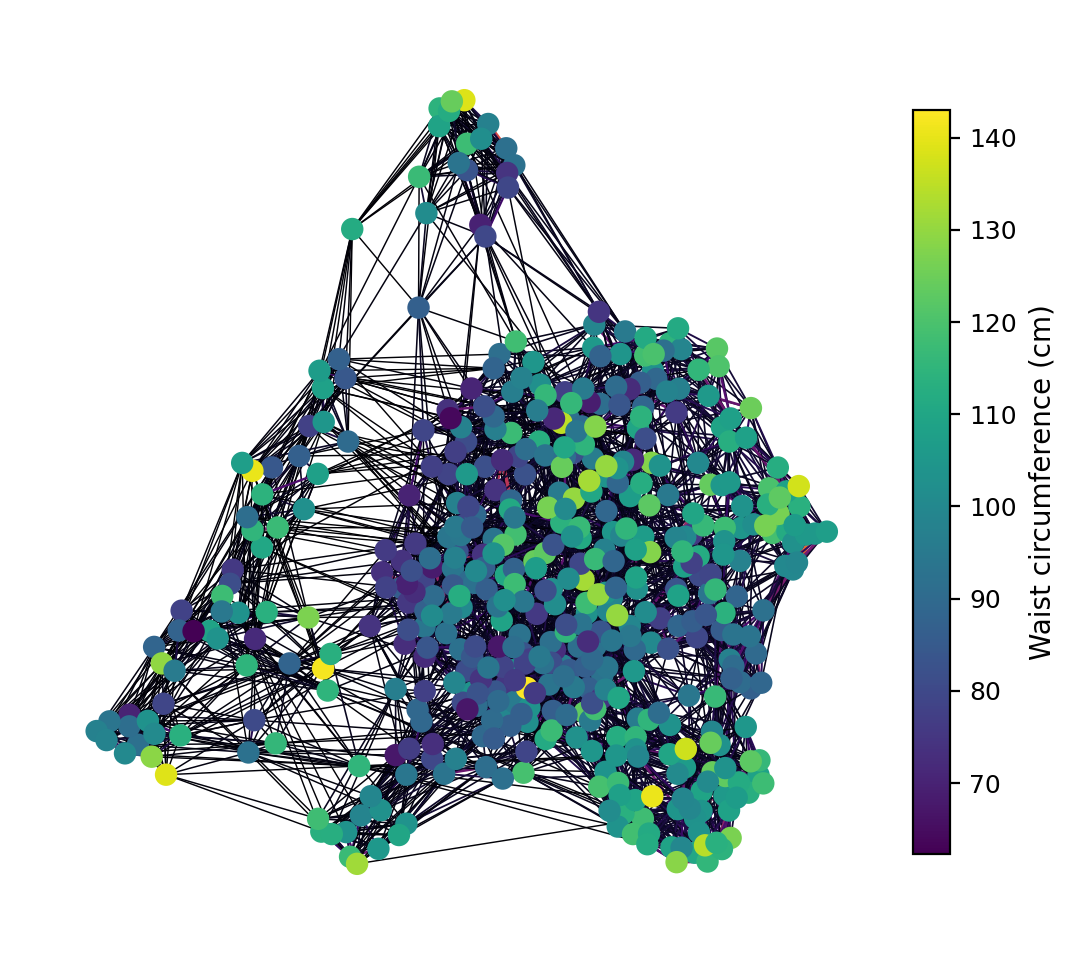

Saved SHAP similarity network.


In [7]:
import snf

# Similarity network built on mutable SHAP values to stay consistent with the clustering
fused_shap = snf.make_affinity(shap_values_mutable, metric='euclidean', K=15, mu=0.5)
n_nodes = fused_shap.shape[0]
K_eff   = max(1, min(15, n_nodes - 1))

top_idx = np.argsort(fused_shap, axis=1)[:, ::-1]
mask    = np.zeros_like(fused_shap, dtype=bool)
for i in range(n_nodes):
    row = top_idx[i]; row = row[row != i][:K_eff]; mask[i, row] = True
mask = np.logical_or(mask, mask.T)

G_shap = nx.Graph()
shap_node_vals = X_test_shap[shap_color_feature].to_numpy()
for i in range(n_nodes):
    G_shap.add_node(i, value=shap_node_vals[i])

ii, jj = np.where(mask)
for i, j in zip(ii, jj):
    if i < j:
        w = fused_shap[i, j]
        if w > 0:
            G_shap.add_edge(i, j, weight=w)

pos_shap = nx.spring_layout(G_shap, seed=42, weight='weight', iterations=300)
ew_shap  = np.array([G_shap[u][v]['weight'] for u, v in G_shap.edges()])
ew_norm  = (ew_shap - ew_shap.min()) / (ew_shap.ptp() + 1e-12)

vals_net = np.array([d['value'] for _, d in G_shap.nodes(data=True)])
vmin_n, vmax_n = np.nanmin(vals_net), np.nanmax(vals_net)

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
ax.set_axis_off()
nx.draw(G_shap, pos_shap, ax=ax, with_labels=False,
        node_color=vals_net, cmap='viridis', vmin=vmin_n, vmax=vmax_n,
        node_size=50, edge_color=[plt.cm.inferno(x) for x in ew_norm],
        width=0.5 + 1.5 * ew_norm)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin_n, vmax=vmax_n))
sm.set_array(vals_net)
cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.01)
cbar.set_label(shap_color_feature, fontsize=10)
cbar.ax.tick_params(labelsize=9)
fig.savefig(f'{output_dir}/shap_similarity_network.png', dpi=300, bbox_inches='tight')
plt.show()

for u, v, d in G_shap.edges(data=True):
    d['weight'] = float(d['weight'])
nx.write_graphml(G_shap, f'{output_dir}/shap_similarity_network.graphml')
print('Saved SHAP similarity network.')


### Cluster Quality Comparison: COALA vs SHAP

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import balanced_accuracy_score
from cf_search.visualize import compute_coala_cluster_metrics

# ── COALA metrics ──────────────────────────────────────────────────────────────
coala_metrics = compute_coala_cluster_metrics(
    archive_data, cell_feature_sets, feature_categories,
    cluster_method=cluster_method, max_k=max_k, force_k=force_k,
    scale=True, reducer=reducer, cv=5)

coala_summary_cv      = coala_metrics['constraint_acc_cv'].mean()
coala_summary_holdout = coala_metrics['constraint_acc_holdout'].mean()

print("COALA cluster metrics (mean across cells):")
print(coala_metrics[['cell','k','n_samples','silhouette','davies_bouldin',
                      'calinski_harabasz','constraint_acc_cv',
                      'constraint_acc_holdout']].to_string(index=False))

# ── SHAP metrics ───────────────────────────────────────────────────────────────
sil_shap = silhouette_score(shap_values_mutable, cluster_labels_shap)
db_shap  = davies_bouldin_score(shap_values_mutable, cluster_labels_shap)
ch_shap  = calinski_harabasz_score(shap_values_mutable, cluster_labels_shap)

X_con = X_test_shap[constraint_features].fillna(X_test_shap[constraint_features].median()).values

# CV
clf_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
shap_acc_cv = cross_val_score(
    clf_cv, X_con, cluster_labels_shap, cv=5, scoring='balanced_accuracy').mean()

# Holdout
try:
    tr_s, te_s = train_test_split(np.arange(len(cluster_labels_shap)), test_size=0.2,
                                   random_state=42, stratify=cluster_labels_shap)
except ValueError:
    tr_s, te_s = train_test_split(np.arange(len(cluster_labels_shap)), test_size=0.2,
                                   random_state=42)
clf_h = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf_h.fit(X_con[tr_s], cluster_labels_shap[tr_s])
shap_acc_holdout = balanced_accuracy_score(
    cluster_labels_shap[te_s], clf_h.predict(X_con[te_s]))

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\nSHAP cluster sizes: { {l: int((cluster_labels_shap==l).sum()) for l in np.unique(cluster_labels_shap)} }")

print("\nConstraint predictability — RF balanced accuracy:")
print(f"  {'':30} {'CV (5-fold)':>12} {'Holdout (20%)':>14}")
print(f"  {'COALA':30} {coala_summary_cv:>12.4f} {coala_summary_holdout:>14.4f}")
print(f"  {'SHAP':30} {shap_acc_cv:>12.4f} {shap_acc_holdout:>14.4f}")

print("\nCOALA vs SHAP — cluster quality (using holdout accuracy):")
print(f"{'Metric':<25} {'COALA':>14} {'SHAP':>10} {'Better':>8}")
print("-" * 60)
rows = [
    ("Silhouette",              coala_metrics['silhouette'].mean(),        sil_shap, "higher"),
    ("Davies-Bouldin",          coala_metrics['davies_bouldin'].mean(),    db_shap,  "lower"),
    ("Calinski-Harabasz",       coala_metrics['calinski_harabasz'].mean(), ch_shap,  "higher"),
    ("Constraint acc (CV)",     coala_summary_cv,      shap_acc_cv,      "higher"),
    ("Constraint acc (holdout)",coala_summary_holdout, shap_acc_holdout, "higher"),
]
for name, cv_val, sv, direction in rows:
    winner = "COALA" if (cv_val > sv) == (direction == "higher") else "SHAP"
    print(f"{name:<25} {cv_val:>14.4f} {sv:>10.4f} {winner:>8}")

COALA cluster metrics (mean across cells):
  cell  k  n_samples  silhouette  davies_bouldin  calinski_harabasz  constraint_acc_cv  constraint_acc_holdout
(0, 0)  3        500    0.469493        1.170546         277.959905           0.927366                0.854106

SHAP cluster sizes: {1: 22, 2: 128, 3: 350}

Constraint predictability — RF balanced accuracy:
                                  CV (5-fold)  Holdout (20%)
  COALA                                0.9274         0.8541
  SHAP                                 0.3421         0.3238

COALA vs SHAP — cluster quality (using holdout accuracy):
Metric                             COALA       SHAP   Better
------------------------------------------------------------
Silhouette                        0.4695     0.3373    COALA
Davies-Bouldin                    1.1705     1.0906     SHAP
Calinski-Harabasz               277.9599   292.6071     SHAP
Constraint acc (CV)               0.9274     0.3421    COALA
Constraint acc (holdout)       

### COALA Evaluation: Additional Metrics
Four metrics that quantify COALA's performance beyond cluster geometry:
- **A** Permutation test — confirms constraint accuracy is non-random
- **B** Fitness distribution — shows counterfactuals actually achieve the target outcome
- **C** Between/within distance ratio — interpretable measure of cluster separation
- **D** Direction consistency heatmap — shows each cluster recommends a coherent, distinct intervention

In [13]:
from sklearn.model_selection import permutation_test_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from cf_search.visualize import optimal_clusters, optimal_hclust_k
import matplotlib.gridspec as gridspec
import seaborn as sns

force_k_eval = force_k if 'force_k' in vars() else None

# ── Re-cluster each cell using the same parameters as the main analysis ────────
cell_eval = {}
for i in range(num_categories):
    for j in range(num_categories):
        cell_key = (i, j)
        df = extract_cell_data(archive_data, cell_key)
        if df.empty or df.shape[0] < 6:
            continue
        mutable = cell_feature_sets[cell_key]
        if not all(f in df.columns for f in mutable):
            continue

        X    = df[mutable].values
        X_sc = StandardScaler().fit_transform(X)

        if cluster_method == 'hierarchal':
            k, labels, _ = optimal_hclust_k(X_sc, max_k=max_k, force_k=force_k_eval)
        else:
            k, labels = optimal_clusters(X_sc, max_k=max_k, force_k=force_k_eval)
            labels = labels + 1

        constraint_cols = [
            c for c in df.columns
            if c not in mutable and c not in ('cell', 'individual_id', 'fitness')
            and '_x_' not in c
        ]
        X_con = df[constraint_cols].fillna(df[constraint_cols].median()).values
        cell_eval[cell_key] = dict(
            df=df, mutable=mutable, constraint_cols=constraint_cols,
            X_sc=X_sc, X_con=X_con, labels=labels, k=k
        )

print(f"Cells evaluated: {list(cell_eval.keys())}")

# ── 1. Permutation test on constraint accuracy ─────────────────────────────────
# Shuffle cluster labels 500 times and recompute RF accuracy each time.
# p-value = fraction of permuted scores >= observed score.
perm_results = {}
for cell_key, res in cell_eval.items():
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    score, perm_scores, p_val = permutation_test_score(
        clf, res['X_con'], res['labels'],
        cv=3, n_permutations=500, scoring='accuracy',
        random_state=42, n_jobs=-1
    )
    perm_results[cell_key] = dict(score=score, perm_scores=np.array(perm_scores), p_val=p_val)
    print(f"Cell {cell_key}: constraint accuracy = {score:.3f},  p = {p_val:.4f}  (500 permutations)")

# ── 2. Fitness distribution ────────────────────────────────────────────────────
all_fitness = np.concatenate([
    v['fitness'].dropna().values
    for v in archive_data.values() if 'fitness' in v.columns
])
print(f"\nFitness (n={len(all_fitness)}): "
      f"mean={all_fitness.mean():.3f},  "
      f"median={np.median(all_fitness):.3f},  "
      f"valid (>0.5): {(all_fitness > 0.5).mean()*100:.1f}%,  "
      f"high  (>0.7): {(all_fitness > 0.7).mean()*100:.1f}%")

# ── 3. Between / within cluster mutable distance ratio ─────────────────────────
# Between = mean pairwise distance between cluster centroids (standardised space).
# Within  = mean distance of each point to its own centroid.
# B/W > 1 means clusters are more spread apart than they are internally dispersed.
bw_results = {}
for cell_key, res in cell_eval.items():
    X_sc, lbls = res['X_sc'], res['labels']
    ul        = np.unique(lbls)
    centroids = np.array([X_sc[lbls == l].mean(axis=0) for l in ul])
    D         = cdist(centroids, centroids)
    between   = D[np.triu_indices(len(ul), k=1)].mean() if len(ul) > 1 else 0.0
    within    = np.mean(np.concatenate([
        np.linalg.norm(X_sc[lbls == l] - centroids[idx], axis=1)
        for idx, l in enumerate(ul)
    ]))
    ratio = between / within if within > 0 else np.inf
    bw_results[cell_key] = dict(between=between, within=within, ratio=ratio)
    print(f"Cell {cell_key}: B/W ratio = {ratio:.3f}  "
          f"(between={between:.3f},  within={within:.3f})")

# ── 4. Direction consistency ───────────────────────────────────────────────────
# Signed consistency: for each (cluster × mutable feature):
#   direction = sign of (cluster CF mean - training population mean)
#   consistency = fraction of CFs in that cluster that agree with the direction
#   reported value = direction × consistency  (sign + magnitude together)
dir_results = {}
for cell_key, res in cell_eval.items():
    df_c, mutable, lbls = res['df'], res['mutable'], res['labels']
    ul    = np.unique(lbls)
    valid = [f for f in mutable if f in df_c.columns and f in ref_df.columns]
    pop_m = ref_df[valid].mean()

    df_tmp         = df_c[valid].copy().reset_index(drop=True)
    df_tmp['_lbl'] = lbls

    rows = []
    for feat in valid:
        pm, row = pop_m[feat], {}
        for l in ul:
            vals = df_tmp.loc[df_tmp['_lbl'] == l, feat].dropna().values
            d    = np.sign(vals.mean() - pm)
            cons = ((vals > pm).mean() if d > 0 else
                    (vals < pm).mean() if d < 0 else 0.5)
            row[l] = float(d * cons)
        rows.append(row)

    dir_df = pd.DataFrame(rows, index=valid)
    dir_df.columns = [f'Cluster {c}' for c in dir_df.columns]
    dir_results[cell_key] = dir_df


Cells evaluated: [(0, 0)]
Cell (0, 0): constraint accuracy = 0.940,  p = 0.0020  (500 permutations)

Fitness (n=500): mean=0.825,  median=0.849,  valid (>0.5): 97.8%,  high  (>0.7): 79.0%
Cell (0, 0): B/W ratio = 2.202  (between=3.687,  within=1.674)


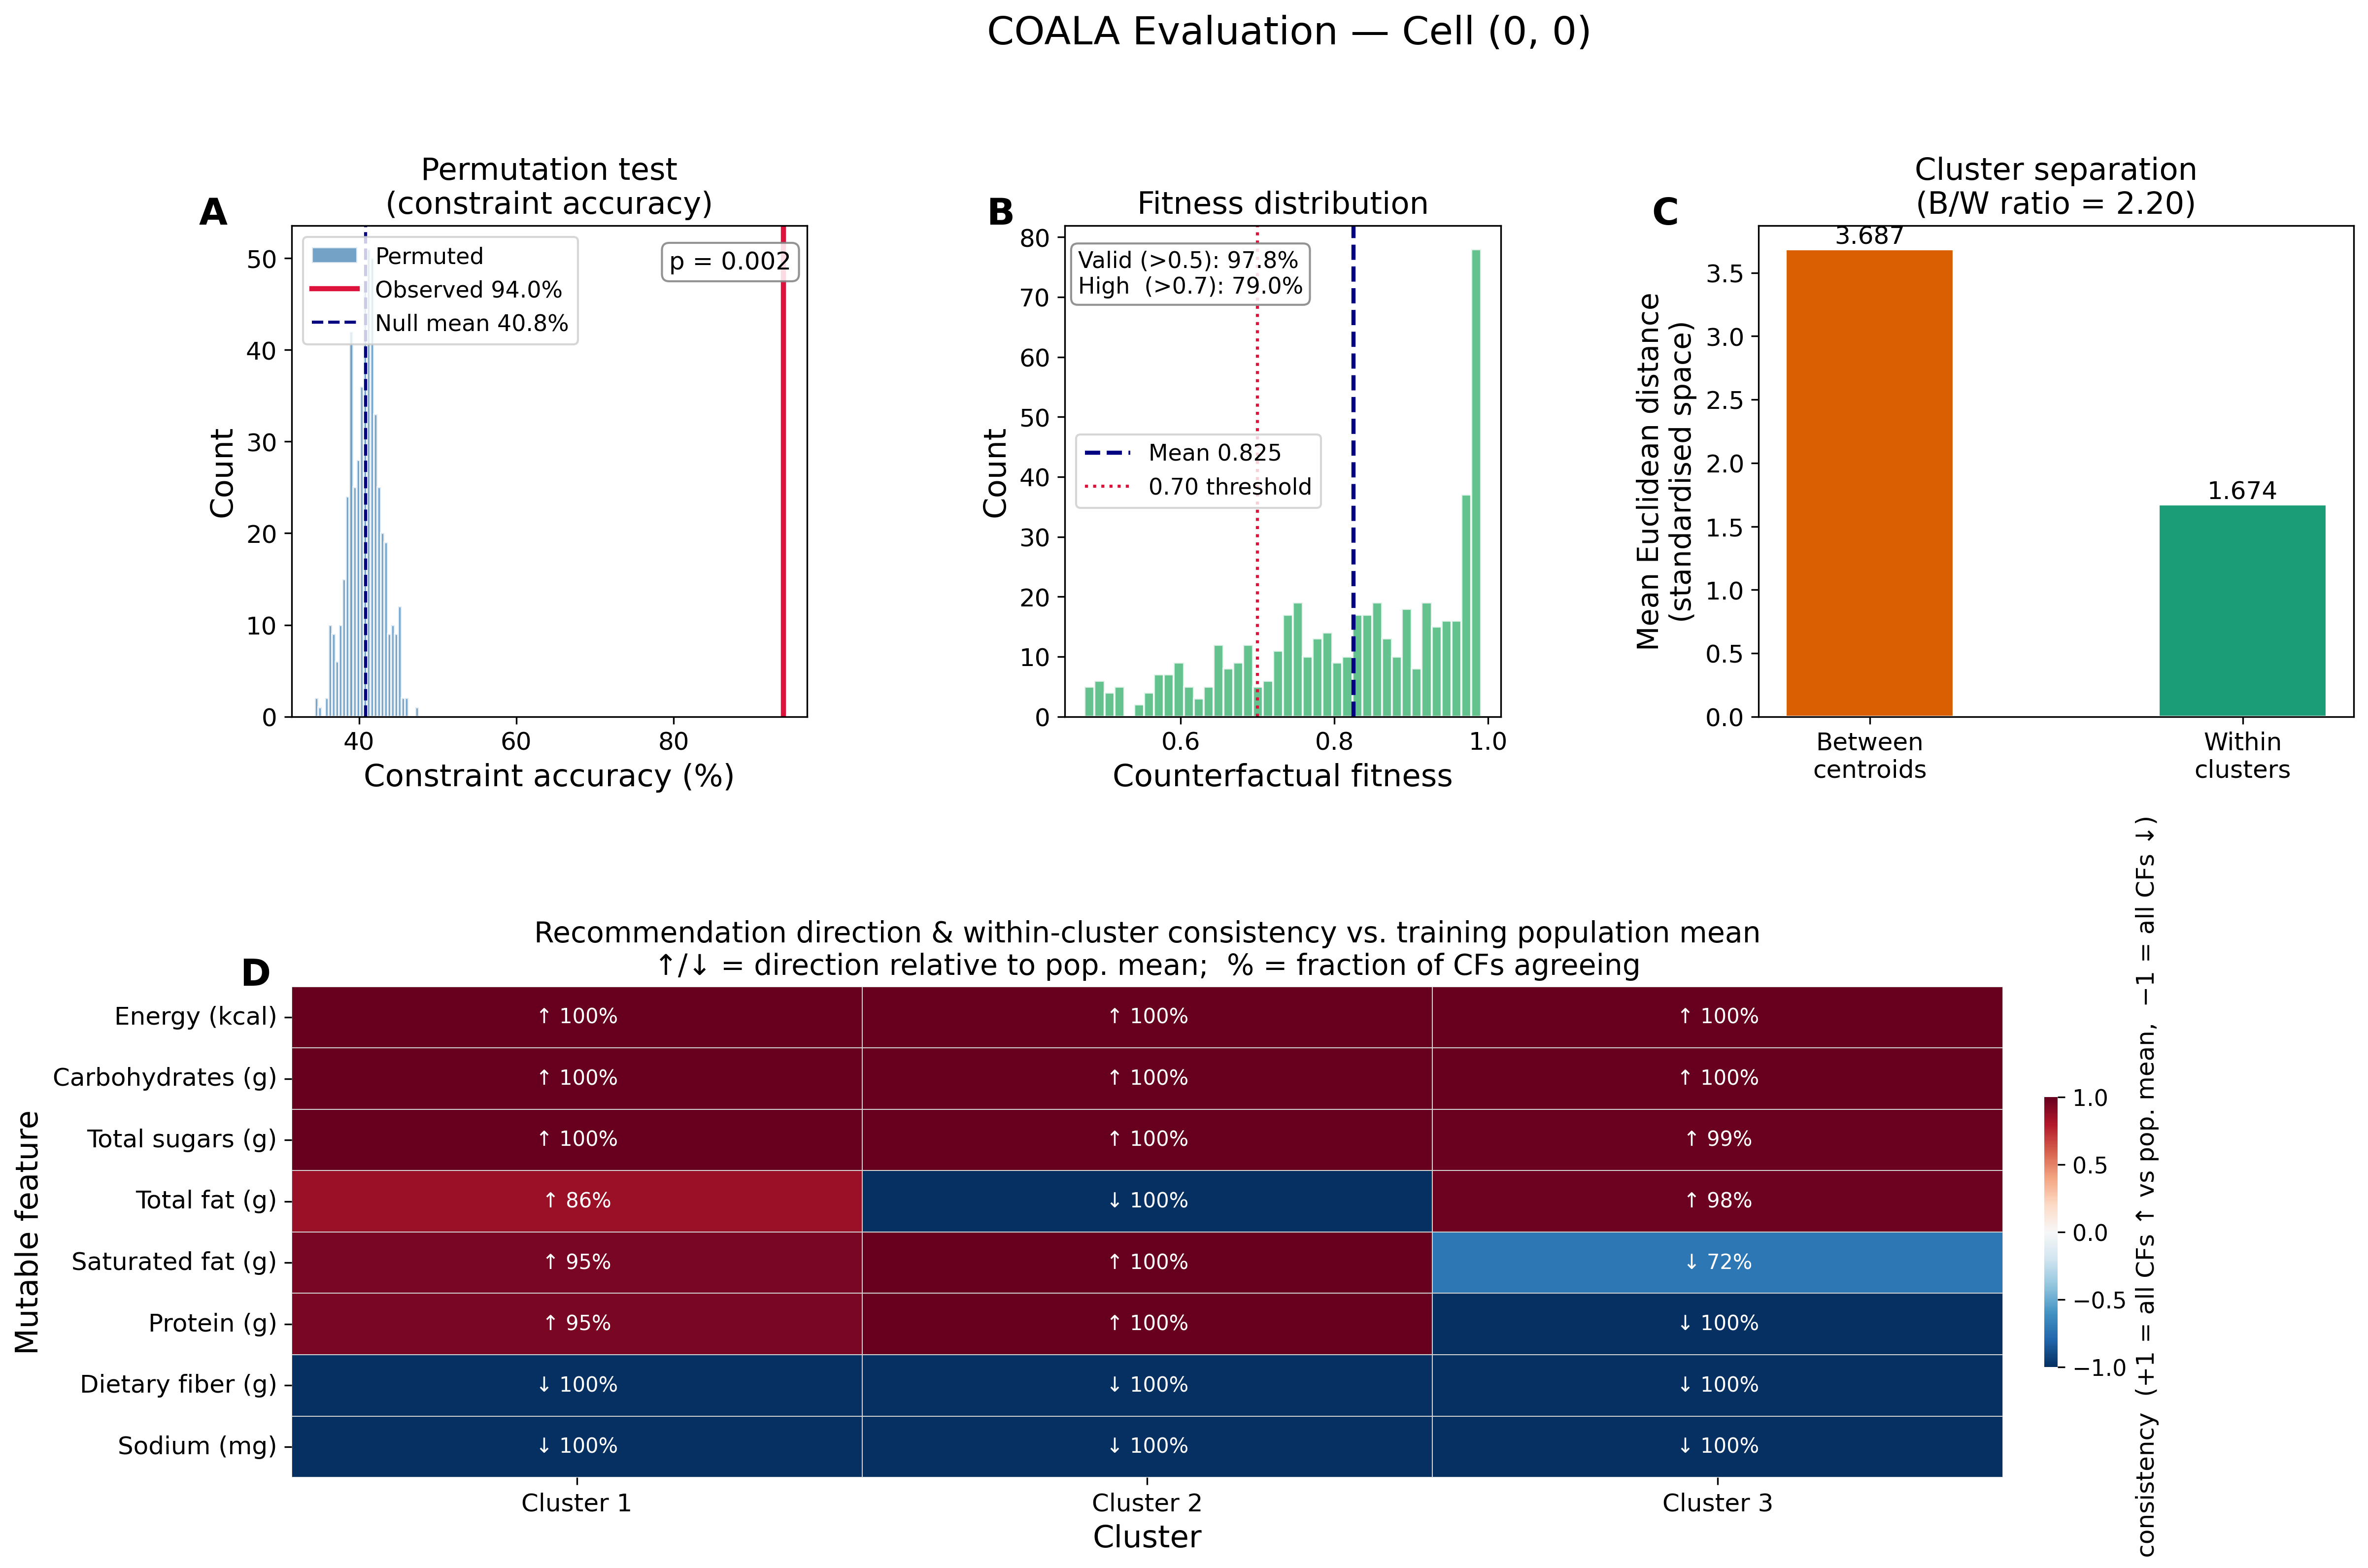

Saved → fhs/xgb_nhanes_diet_output/coala_eval_metrics.png


In [14]:
# ── Combined evaluation figure ─────────────────────────────────────────────────
sfs, tfs, afs = 15, 12, 10

for cell_key in cell_eval:
    pr     = perm_results[cell_key]
    bwr    = bw_results[cell_key]
    dir_df = dir_results[cell_key]

    fig = plt.figure(figsize=(18, 11), dpi=300)
    gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.5, hspace=0.55,
                            width_ratios=[1.3, 1.1, 1.5])

    # Panel A — Permutation test
    ax_A = fig.add_subplot(gs[0, 0])
    ax_A.hist(pr['perm_scores'] * 100, bins=30,
              color='steelblue', alpha=0.75, edgecolor='white', label='Permuted')
    ax_A.axvline(pr['score'] * 100, color='crimson', lw=2.5,
                 label=f"Observed {pr['score']*100:.1f}%")
    ax_A.axvline(pr['perm_scores'].mean() * 100, color='navy', lw=1.5, linestyle='--',
                 label=f"Null mean {pr['perm_scores'].mean()*100:.1f}%")
    p_str = 'p < 0.001' if pr['p_val'] < 0.001 else f"p = {pr['p_val']:.3f}"
    ax_A.text(0.97, 0.95, p_str, transform=ax_A.transAxes,
              ha='right', va='top', fontsize=tfs,
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.85))
    ax_A.set_xlabel('Constraint accuracy (%)', fontsize=sfs)
    ax_A.set_ylabel('Count', fontsize=sfs)
    ax_A.set_title('Permutation test\n(constraint accuracy)', fontsize=sfs)
    ax_A.legend(fontsize=tfs - 1, loc='upper left')
    ax_A.tick_params(labelsize=tfs)
    ax_A.text(-0.18, 1.06, 'A', transform=ax_A.transAxes,
              fontsize=sfs + 3, fontweight='bold', va='top')

    # Panel B — Fitness distribution
    ax_B = fig.add_subplot(gs[0, 1])
    ax_B.hist(all_fitness, bins=40, color='mediumseagreen', alpha=0.8, edgecolor='white')
    ax_B.axvline(all_fitness.mean(), color='navy', lw=2, linestyle='--',
                 label=f'Mean {all_fitness.mean():.3f}')
    ax_B.axvline(0.7, color='crimson', lw=1.5, linestyle=':', label='0.70 threshold')
    pct_valid = (all_fitness > 0.5).mean() * 100
    pct_high  = (all_fitness > 0.7).mean() * 100
    ax_B.text(0.03, 0.95,
              f'Valid (>0.5): {pct_valid:.1f}%\nHigh  (>0.7): {pct_high:.1f}%',
              transform=ax_B.transAxes, fontsize=tfs - 1, va='top',
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.85))
    ax_B.set_xlabel('Counterfactual fitness', fontsize=sfs)
    ax_B.set_ylabel('Count', fontsize=sfs)
    ax_B.set_title('Fitness distribution', fontsize=sfs)
    ax_B.legend(fontsize=tfs - 1)
    ax_B.tick_params(labelsize=tfs)
    ax_B.text(-0.18, 1.06, 'B', transform=ax_B.transAxes,
              fontsize=sfs + 3, fontweight='bold', va='top')

    # Panel C — Between / within cluster distance
    ax_C = fig.add_subplot(gs[0, 2])
    bars = ax_C.bar(['Between\ncentroids', 'Within\nclusters'],
                    [bwr['between'], bwr['within']],
                    color=['#D95F02', '#1B9E77'], width=0.45, edgecolor='white')
    for b, v in zip(bars, [bwr['between'], bwr['within']]):
        ax_C.text(b.get_x() + b.get_width() / 2, v + 0.005,
                  f'{v:.3f}', ha='center', va='bottom', fontsize=tfs)
    ax_C.set_ylabel('Mean Euclidean distance\n(standardised space)', fontsize=sfs - 1)
    ax_C.set_title(f'Cluster separation\n(B/W ratio = {bwr["ratio"]:.2f})', fontsize=sfs)
    ax_C.tick_params(labelsize=tfs)
    ax_C.text(-0.18, 1.06, 'C', transform=ax_C.transAxes,
              fontsize=sfs + 3, fontweight='bold', va='top')

    # Panel D — Direction consistency heatmap (spans full bottom row)
    ax_D  = fig.add_subplot(gs[1, :])
    dv    = dir_df.astype(float)
    annot = np.empty(dv.shape, dtype=object)
    for r in range(dv.shape[0]):
        for c in range(dv.shape[1]):
            v = dv.iloc[r, c]
            annot[r, c] = f'{"↑" if v > 0 else "↓" if v < 0 else "→"} {abs(v)*100:.0f}%'

    hm = sns.heatmap(dv, ax=ax_D, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                     annot=annot, fmt='', annot_kws={'size': afs},
                     linewidths=0.4, linecolor='lightgrey',
                     cbar_kws={'shrink': 0.55, 'pad': 0.02})
    ax_D.set_xlabel('Cluster', fontsize=sfs)
    ax_D.set_ylabel('Mutable feature', fontsize=sfs)
    ax_D.set_title(
        'Recommendation direction & within-cluster consistency vs. training population mean\n'
        '↑/↓ = direction relative to pop. mean;  % = fraction of CFs agreeing',
        fontsize=sfs - 1)
    ax_D.tick_params(axis='x', labelsize=tfs, rotation=0)
    ax_D.tick_params(axis='y', labelsize=tfs, rotation=0)
    hm.collections[0].colorbar.set_label(
        'Signed consistency  (+1 = all CFs ↑ vs pop. mean,  −1 = all CFs ↓)', fontsize=tfs)
    hm.collections[0].colorbar.ax.tick_params(labelsize=tfs - 1)
    ax_D.text(-0.03, 1.06, 'D', transform=ax_D.transAxes,
              fontsize=sfs + 3, fontweight='bold', va='top')

    fig.suptitle(f'COALA Evaluation — Cell {cell_key}', fontsize=sfs + 4, y=1.01)
    out = f'{output_dir}/coala_eval_metrics.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')
